# HAT Clustering Analysis — Emotional vs Neutral

Each data point is one isolated inference trial. The server is reset, caches are dropped,
and a 2-second stabilisation baseline is observed before every trial.

**Data layout per trial** (`runs/<label>/p<NNNN>/`):
```
perf_stat.csv        — 1ms buckets, 24 perf events (HAT Layer 1 tracepoints + Layer 2 PMU/power)
hat_interrupts.csv   — 100ms: /proc/interrupts, /proc/softirqs, CPU freq per core
proc_sample.csv      — 100ms: system + per-process CPU jiffies, RSS
collector_meta.json  — t0_ns, duration, perf_events list
trial_meta.json      — prompt_index, label, ok, elapsed_ms
```

**Analysis pipeline:**
1. Load pre-extracted feature CSVs (one row per trial, one column per indicator×metric)
2. Confounder check: verify `elapsed_ms` is balanced between conditions
3. Feature selection: exclude artefact indicators and optionally length-confounded metrics
4. Univariate screening: Mann-Whitney U + Bonferroni correction per feature
5. Per-feature k=2 clustering (k-means + GMM) → composite ranking
6. Multi-feature GMM K-sweep on top-K features
7. PCA visualisation of cluster structure
8. Per-indicator × per-metric grid: finest-grained view of which (indicator, metric) pair drives separation
9. Test set evaluation with elapsed_ms residualisation


## 1 — Imports

In [550]:
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')


Imports OK


## 2 — Configuration

In [551]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'

print(f'BASE_DIR = {BASE_DIR}')
assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'


BASE_DIR = /Users/rsalvi/Desktop/mccviahat


## 3 — Load features

In [552]:
_node = 'clemsonc6420'
_data_dir = BASE_DIR / 'data' / _node

_csvTOT = _data_dir / 'independentF.csv'

assert _csvTOT.exists(), (
    f'{_csvTOT.name} not found at {_csvTOT}\n'
    'Run: python scripts/run/extract_features.py'
)

df_all = pd.read_csv(_csvTOT)

# ── Results directory ────────────────────────────────────────────────
RESULTS_DIR = BASE_DIR / 'results' / _csvTOT.stem
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results → {RESULTS_DIR}')

# ── Join token counts (n_tokens confounder) ───────────────────────────────
_token_csv = BASE_DIR / 'prompts' / '20base' / 'combined_token_counts.csv'
if _token_csv.exists():
    _tok_df = pd.read_csv(_token_csv)[['condition', 'prompt_index', 'n_tokens', 'title']]
    df_all = df_all.merge(_tok_df, on=['condition', 'prompt_index'], how='left')
    _missing = df_all['n_tokens'].isna().sum()
    print(f'  Joined n_tokens from {_token_csv.name}  '
          f'(matched {len(df_all) - _missing}/{len(df_all)} trials'
          + (f', {_missing} unmatched' if _missing else '') + ')')
else:
    df_all['n_tokens'] = np.nan
    print(f'  ⚠  Token counts not found at {_token_csv}')

print(f'Loaded: {_csvTOT}')
print(f'  {len(df_all)} trials total  |  '
      f'neutral: {(df_all.condition=="neutral").sum()}  |  '
      f'emotional: {(df_all.condition=="emotional").sum()}')
print(f'  Feature columns: {len([c for c in df_all.columns if "__" in c])}')


Results → /Users/rsalvi/Desktop/mccviahat/results/independentF
  ⚠  Token counts not found at /Users/rsalvi/Desktop/mccviahat/prompts/20base/combined_token_counts.csv
Loaded: /Users/rsalvi/Desktop/mccviahat/data/clemsonc6420/independentF.csv
  40 trials total  |  neutral: 20  |  emotional: 20
  Feature columns: 550


## 4 — Confounder check: elapsed_ms and n_tokens

If `elapsed_ms` or `n_tokens` (prompt token count) differs significantly between
conditions, any metric that scales with duration or input length is a confounder
rather than a true substrate signal. We check both and set the `LENGTH_CONFOUNDED`
flag used downstream.


In [553]:
from scipy import stats as sp_stats

# ── elapsed_ms ────────────────────────────────────────────────────────────────
# Ensure numeric (the CSV may store elapsed_ms as strings)
df_all['elapsed_ms'] = pd.to_numeric(df_all['elapsed_ms'], errors='coerce')

dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_len = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms:  mean={dur_n.mean():.0f} ms, median={np.median(dur_n):.0f} ms, n={len(dur_n)}')
print(f'Emotional elapsed_ms:  mean={dur_e.mean():.0f} ms, median={np.median(dur_e):.0f} ms, n={len(dur_e)}')
print(f'Mann-Whitney U={stat:.0f},  p={p_len:.4g}')
if p_len < 0.05:
    print('⚠  elapsed_ms differs significantly between conditions (p < 0.05).')
    print('   Metrics that scale with duration may be confounded by prompt length.')
else:
    print('✓  No significant difference in elapsed_ms between conditions.')

# ── n_tokens ──────────────────────────────────────────────────────────────────
print()
if df_all['n_tokens'].notna().any():
    tok_n = df_all.loc[df_all.condition == 'neutral',   'n_tokens'].dropna().values
    tok_e = df_all.loc[df_all.condition == 'emotional', 'n_tokens'].dropna().values
    stat_t, p_tok = sp_stats.mannwhitneyu(tok_n, tok_e, alternative='two-sided')
    print(f'Neutral   n_tokens:    mean={tok_n.mean():.0f},  median={np.median(tok_n):.0f},  n={len(tok_n)}')
    print(f'Emotional n_tokens:    mean={tok_e.mean():.0f},  median={np.median(tok_e):.0f},  n={len(tok_e)}')
    print(f'Mann-Whitney U={stat_t:.0f},  p={p_tok:.4g}')
    if p_tok < 0.05:
        print('⚠  n_tokens differs significantly between conditions (p < 0.05).')
        print('   Metrics that scale with input length may also be confounded.')
    else:
        print('✓  No significant difference in n_tokens between conditions.')
else:
    p_tok = np.nan
    print('n_tokens: not available — run:')
    print('  python scripts/run/token_count_csv.py \\')
    print('    prompts/20base/independentE.json prompts/20base/independentN.json')

LENGTH_CONFOUNDED = p_len < 0.05
print(f'\nLength confound flag (elapsed_ms): LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')

# Shared bin edges for the elapsed_ms histogram below
all_dur = np.concatenate([dur_n, dur_e])
bins = np.linspace(all_dur.min(), all_dur.max(), 30)

Neutral   elapsed_ms:  mean=22754 ms, median=22703 ms, n=20
Emotional elapsed_ms:  mean=23328 ms, median=23269 ms, n=20
Mann-Whitney U=142,  p=0.1199
✓  No significant difference in elapsed_ms between conditions.

n_tokens: not available — run:
  python scripts/run/token_count_csv.py \
    prompts/20base/independentE.json prompts/20base/independentN.json

Length confound flag (elapsed_ms): LENGTH_CONFOUNDED = False


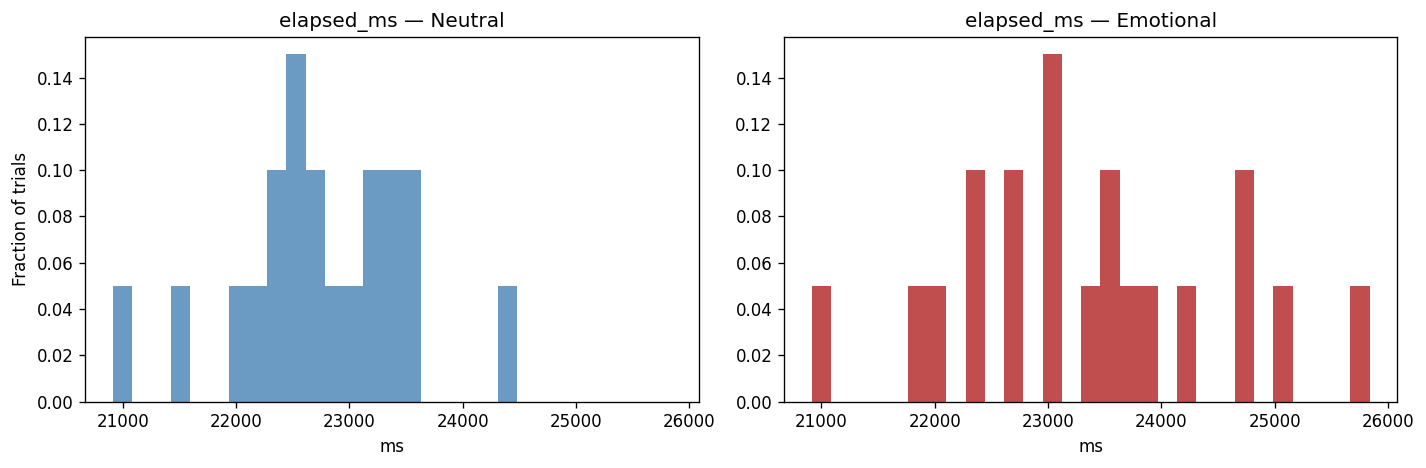


Length confound flag: LENGTH_CONFOUNDED = False
Note: mean_rate is normalised by dur_s — NOT confounded by length.
Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.


In [554]:
weights_n = np.ones(len(dur_n)) / len(dur_n)
weights_e = np.ones(len(dur_e)) / len(dur_e)

has_tokens = df_all['n_tokens'].notna().any()
n_panels = 4 if has_tokens else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 4))

axes[0].hist(dur_n, bins=bins, weights=weights_n, color='steelblue', alpha=0.8, label='neutral')
axes[0].set_title('elapsed_ms — Neutral')
axes[0].set_xlabel('ms'); axes[0].set_ylabel('Fraction of trials')

axes[1].hist(dur_e, bins=bins, weights=weights_e, color='firebrick', alpha=0.8, label='emotional')
axes[1].set_title('elapsed_ms — Emotional')
axes[1].set_xlabel('ms')

if has_tokens:
    tok_bins = np.linspace(df_all['n_tokens'].min(), df_all['n_tokens'].max(), 20)
    w_tn = np.ones(len(tok_n)) / len(tok_n)
    w_te = np.ones(len(tok_e)) / len(tok_e)
    axes[2].hist(tok_n, bins=tok_bins, weights=w_tn, color='steelblue', alpha=0.8)
    axes[2].set_title('n_tokens — Neutral')
    axes[2].set_xlabel('tokens'); axes[2].set_ylabel('Fraction of trials')
    axes[3].hist(tok_e, bins=tok_bins, weights=w_te, color='firebrick', alpha=0.8)
    axes[3].set_title('n_tokens — Emotional')
    axes[3].set_xlabel('tokens')

plt.tight_layout()
plt.show()

print(f'\nLength confound flag: LENGTH_CONFOUNDED = {LENGTH_CONFOUNDED}')
print('Note: mean_rate is normalised by dur_s — NOT confounded by length.')
print('Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.')
if has_tokens:
    print(f'n_tokens confounder: p={p_tok:.4g}  '
          + ('⚠ significant' if p_tok < 0.05 else '✓ not significant'))


## 5 — Feature selection

Three filtering steps are applied in sequence:

1. **Length-confounded metrics** — if `LENGTH_CONFOUNDED=True`, optionally exclude metrics
   not normalised by duration (`variance`, `p90_p10`, `lz_complexity`, `perm_entropy`, `spectral_entropy`).
2. **Artefact / noise indicators** — hard-exclude indicators that are measurement artefacts
   or pure OS noise unrelated to inference (`hat_PMI`, `hat_NMI`, `hat_LOC`, `hat_RES`,
   `hat_CAL`, `hat_MCP`, `cpu_freq`).
3. **Correlation pruning** — for each pair with |Pearson r| > 0.95, drop the lower-variance one.


In [555]:
# --- Feature selection: include/exclude length-confounded features ---
from typing import List

# List of metrics that may be length-confounded
LENGTH_CONFOUNDED_METRICS = {
    'variance', 'p90_p10', 'lz_complexity', 'perm_entropy', 'spectral_entropy'
}

feature_cols = [c for c in df_all.columns if '__' in c]

def metric_of(col: str) -> str:
    # evt__metric
    return col.split('__', 1)[1]

length_confounded_cols   = [c for c in feature_cols if metric_of(c) in LENGTH_CONFOUNDED_METRICS]
length_unconfounded_cols = [c for c in feature_cols if metric_of(c) not in LENGTH_CONFOUNDED_METRICS]

print(f"Length-confounded features: {len(length_confounded_cols)}")
print(f"Length-unconfounded features: {len(length_unconfounded_cols)}")

# User selection: set to True to include, False to exclude length-confounded features
INCLUDE_LENGTH_CONFOUNDED = True  # <-- change this to True to include them

if INCLUDE_LENGTH_CONFOUNDED:
    selected_cols = length_unconfounded_cols + length_confounded_cols
    print("Including ALL features (length-confounded and unconfounded).")
else:
    selected_cols = length_unconfounded_cols
    print("Excluding length-confounded features.")

# Subset the feature matrix for downstream analysis
X = df_all[selected_cols].copy()
print(f"Final feature matrix shape: {X.shape}")

Length-confounded features: 275
Length-unconfounded features: 275
Including ALL features (length-confounded and unconfounded).
Final feature matrix shape: (40, 550)
Final feature matrix shape: (40, 550)


### Build and clean feature matrix

In [556]:
# --- Build feature matrix and clean ---
# Use selected_cols from previous cell (already filtered for confounding)

# n_tokens and title are metadata/confounders — exclude from feature matrix
META_COLS = {'condition', 'prompt_index', 'elapsed_ms', 'dur_s', 'n_tokens', 'title'}
feat_cols = [c for c in X.columns if c not in META_COLS]

X_raw = X[feat_cols].apply(pd.to_numeric, errors='coerce')
y = (df_all['condition'] == 'emotional').astype(int).values  # 0=neutral, 1=emotional

# Drop zero-variance columns and fill NaN
X_raw = X_raw.loc[:, X_raw.std() > 0]
X_raw = X_raw.fillna(X_raw.median())

feat_cols = list(X_raw.columns)
print(f'Feature matrix: {X_raw.shape[0]} samples × {X_raw.shape[1]} features')

# Standardise
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)
print('Standardised.')

Feature matrix: 40 samples × 345 features
Standardised.


In [557]:
# ── Signal-quality mask ─────────────────────────────────────────────────────
# Based on the physiological interpretation of each hardware/OS counter.
# Indicators are the prefix before '__' in column names (e.g. hat_TLB, cache-misses).
#
# Tier 1 — Primary computation-coupled signals (direct inference substrate signals)
PRIMARY_SIGNALS = {
    'tlb:tlb_flush',          # hardware TLB shootdown — direct VM pressure
    'LLC-load-misses',        # DRAM fetches from model weight access
    'cache-misses',           # L1/L2 cache pressure from inference
    'cache-references',       # L1/L2 cache references
    'dTLB-load-misses',       # data TLB misses during weight tensor loads
    'branch-misses',          # branch predictor misses shaped by inference control flow
    'branch-instructions',    # total branch count
    'instructions',           # raw computational throughput
    'cycles',                 # CPU cycle count
    'core_power.throttle',    # thermal throttle from sustained inference load
}

# Tier 2 — Computation-coupled but indirect (keep, interpret with caveats)
INDIRECT_SIGNALS = {
    'power/energy-pkg/',      # RAPL package energy
    'power/energy-ram/',      # RAPL RAM energy
    'msr/cpu_thermal_margin/',# thermal margin (slow-moving, session-level)
    'irq:irq_handler_exit',   # all IRQ completions — inference-coupled but noisy
    'irq:softirq_raise',      # softirq scheduling — computation-coupled, aggregated
}

# Tier 3 — Confounder controls (keep but do NOT interpret as substrate signals)
CONFOUNDER_CONTROLS = {
    'context-switches',       # scheduling artefact; if differs, explains hw counter diffs
    'cpu-migrations',         # scheduling/migration artefact
    'page-faults',            # mmap weight access (minor) + noise (major)
    'cpu-clock',              # duration normaliser
}

# Tier 4 — HAT substrate signals (hat__ prefix indicators to keep)
HAT_PRIMARY = {
    'hat_TLB',   # TLB shootdown IPIs — direct VM pressure from inference
    'hat_BLOCK', # block I/O softirq — memory pressure / page reclaim during weight access
    'hat_IWI',   # interprocessor wakeup IRQs — NUMA memory access patterns
}

# Tier 5 — HAT scheduling-coupled (keep with caveats)
HAT_SCHEDULING = {
    'hat_NET_RX',  # scheduler side-effect of CPU occupancy
    'hat_NET_TX',
    'hat_SCHED',   # scheduler softirq — modulated by inference CPU demand
    'hat_RCU',     # RCU callbacks — loosely correlated with kernel activity
    'hat_TIMER',   # timer softirq — partially fixed-rate, partially load-dependent
}

# Exclude — measurement artefact or pure OS noise unrelated to inference
EXCLUDE_INDICATORS = {
    'hat_PMI',   # perf's own sampling interrupts — artefact, not inference-related
    'hat_NMI',   # non-maskable interrupt counts — hardware artefact
    'hat_LOC',   # local APIC timer — fires at fixed kernel tick rate, ignores inference
    'hat_RES',   # rescheduling IPIs — scheduler load balancing, not inference
    'hat_CAL',   # function-call IPIs — OS housekeeping
    'hat_MCP',   # machine check polls — periodic kernel health, not inference-driven
    'cpu_freq',  # DVFS governor — consequence of power policy, not a substrate signal
}

def _indicator_of(col: str) -> str:
    """Return the indicator prefix of a column named 'indicator__metric'."""
    return col.split('__', 1)[0]

_before = len(feat_cols)
feat_cols = [
    c for c in feat_cols
    if _indicator_of(c) not in EXCLUDE_INDICATORS
]
_excluded = _before - len(feat_cols)

X_raw = X_raw[feat_cols].copy()
X     = X[feat_cols].copy()

print(f'Signal-quality mask:')
print(f'  Excluded {_excluded} columns from {_before} '
      f'({", ".join(sorted(EXCLUDE_INDICATORS))})')
print(f'  Remaining: {len(feat_cols)} features')


Signal-quality mask:
  Excluded 54 columns from 345 (cpu_freq, hat_CAL, hat_LOC, hat_MCP, hat_NMI, hat_PMI, hat_RES)
  Remaining: 291 features


In [558]:

# ── Correlation pruning ──────────────────────────────────────────────
# For each pair of features with |Pearson r| > 0.95, drop the one with
# lower variance (less informative), keeping the more variable one.
CORR_THRESHOLD = 0.95

corr_matrix = X_raw.corr().abs()
# Upper triangle only (avoid double-counting pairs)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
)

# For each column, collect all its partners that exceed threshold
# Sort features by variance descending so we always keep the most variable
feat_var = X_raw.var().sort_values(ascending=False)
ordered  = feat_var.index.tolist()   # high-variance features first

to_drop = set()
for feat in ordered:
    if feat in to_drop:
        continue
    # Partners with correlation > threshold that haven't been dropped yet
    partners = upper.index[upper[feat] > CORR_THRESHOLD].tolist() if feat in upper.columns else []
    for partner in partners:
        if partner not in to_drop:
            # Drop the lower-variance one (partner comes later in `ordered`)
            to_drop.add(partner)

X_raw    = X_raw.drop(columns=list(to_drop))
feat_cols = list(X_raw.columns)

# Re-standardise after pruning
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)

print(f'Correlation pruning (|r| > {CORR_THRESHOLD}):')
print(f'  Dropped : {len(to_drop)} features')
print(f'  Kept    : {len(feat_cols)} features')


Correlation pruning (|r| > 0.95):
  Dropped : 71 features
  Kept    : 220 features


In [559]:
# --- Diagnostics: Check feature selection logic ---
print(f"INCLUDE_LENGTH_CONFOUNDED = {INCLUDE_LENGTH_CONFOUNDED}")
print(f"Length-confounded features matched: {len(length_confounded_cols)}")
print(f"Length-unconfounded features matched: {len(length_unconfounded_cols)}")
print(f"Selected columns: {len(selected_cols)}")
print(f"Final feature matrix shape after cleaning: {X.shape}")

INCLUDE_LENGTH_CONFOUNDED = True
Length-confounded features matched: 275
Length-unconfounded features matched: 275
Selected columns: 550
Final feature matrix shape after cleaning: (40, 220)


## 6 — Univariate screening: Mann-Whitney U

Non-parametric test for each feature. We report the rank-biserial effect size *r* and direction.
Bonferroni correction is applied across all features tested simultaneously.


In [560]:
results = []
n_vals = X_raw[y == 0]
e_vals = X_raw[y == 1]

for col in feat_cols:
    nv = n_vals[col].dropna().values
    ev = e_vals[col].dropna().values
    if len(nv) < 5 or len(ev) < 5:
        continue
    if nv.std() == 0 and ev.std() == 0:
        continue
    stat, p = sp_stats.mannwhitneyu(nv, ev, alternative='two-sided')
    r = 1 - (2 * stat) / (len(nv) * len(ev))  # rank-biserial r
    results.append({
        'feature':   col,
        'U':         stat,
        'p':         p,
        'effect_r':  r,
        'n_mean':    nv.mean(),
        'e_mean':    ev.mean(),
        'direction': '↑E' if ev.mean() > nv.mean() else '↓E',
    })

mwu_df = pd.DataFrame(results).sort_values('p').reset_index(drop=True)

# Bonferroni-corrected threshold
alpha_raw = 0.05
alpha_bonf = alpha_raw / len(mwu_df)
sig_strict = mwu_df[mwu_df.p < alpha_bonf]
sig_nominal = mwu_df[mwu_df.p < alpha_raw]

print(f'Features tested: {len(mwu_df)}')
print(f'Significant at p<{alpha_raw} (nominal):    {len(sig_nominal)}')
print(f'Significant at p<{alpha_bonf:.2e} (Bonferroni): {len(sig_strict)}')
print()
print('=== Top 30 features by p-value ===')
print(mwu_df.head(30)[['feature', 'U', 'p', 'effect_r', 'direction']].to_string(
    index=False, float_format='{:.4f}'.format))

mwu_df.to_csv('pvalF.csv')

Features tested: 220
Significant at p<0.05 (nominal):    39
Significant at p<2.27e-04 (Bonferroni): 0

=== Top 30 features by p-value ===
                               feature        U      p  effect_r direction
                page-faults__mean_rate 330.0000 0.0005   -0.6500        ↓E
           dTLB-load-misses__mean_rate 324.0000 0.0008   -0.6200        ↓E
                  page-faults__p90_p10 319.5000 0.0013   -0.5975        ↓E
    core_power.throttle__lz_complexity  83.0000 0.0016    0.5850        ↑E
               cpu-migrations__p90_p10 308.0000 0.0032   -0.5400        ↓E
                tlb:tlb_flush__p90_p10 301.5000 0.0044   -0.5075        ↓E
             page-faults__perm_entropy 302.0000 0.0060   -0.5100        ↓E
            cache-references__variance 300.0000 0.0071   -0.5000        ↓E
                      hat_TLB__p90_p10 299.0000 0.0077   -0.4950        ↓E
       context-switches__lz_complexity 101.0000 0.0077    0.4950        ↑E
                    hat_SCHED__p90_p1

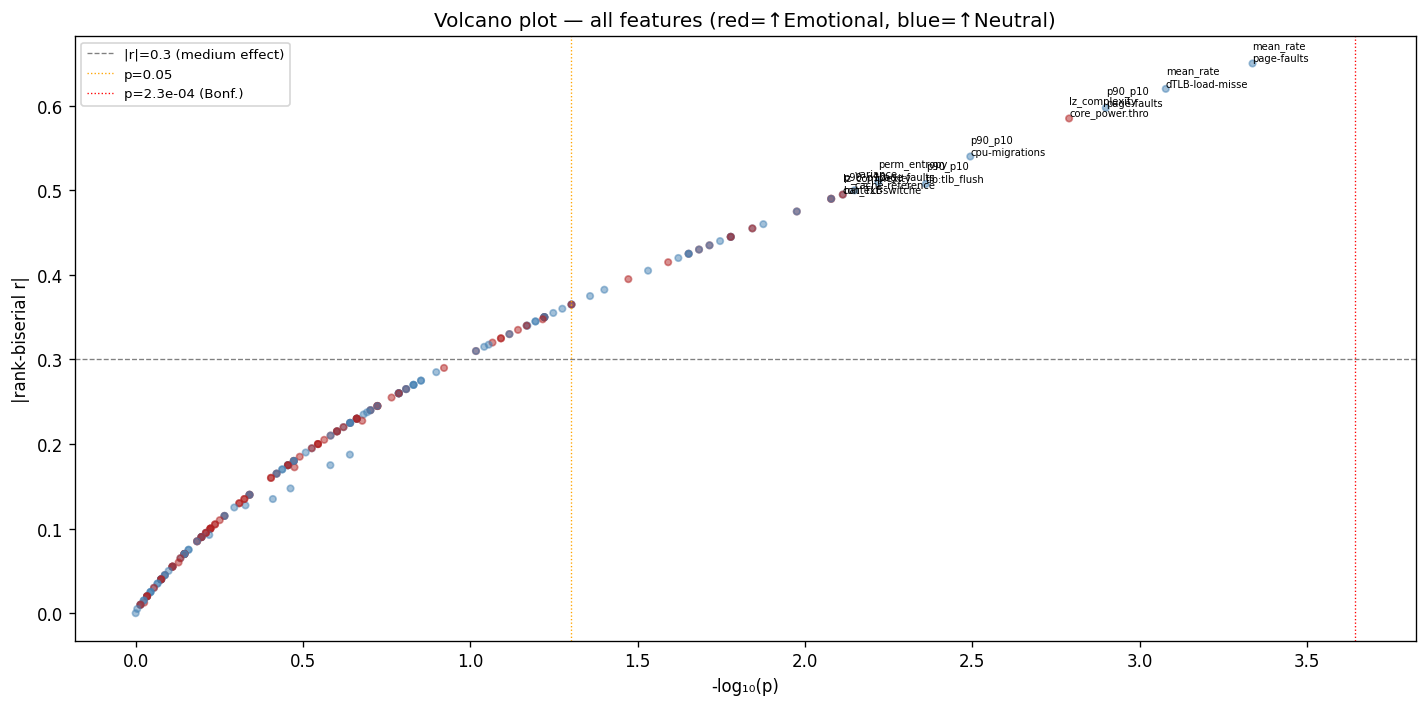

In [561]:
# Volcano plot: effect size vs -log10(p)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['firebrick' if r > 0 else 'steelblue' for r in mwu_df.effect_r]
ax.scatter(-np.log10(mwu_df.p + 1e-15), mwu_df.effect_r.abs(),
           c=colors, alpha=0.5, s=15)
ax.axhline(0.3, ls='--', color='gray', lw=0.8, label='|r|=0.3 (medium effect)')
ax.axvline(-np.log10(alpha_raw), ls=':', color='orange', lw=0.8, label=f'p={alpha_raw}')
ax.axvline(-np.log10(alpha_bonf), ls=':', color='red', lw=0.8, label=f'p={alpha_bonf:.1e} (Bonf.)')
# Label top 10
for _, row in mwu_df.head(10).iterrows():
    ax.annotate(row.feature.split('__')[-1] + '\n' + row.feature.split('__')[0][:15],
                xy=(-np.log10(row.p + 1e-15), abs(row.effect_r)),
                fontsize=6, ha='left', va='bottom')
ax.set_xlabel('-log₁₀(p)')
ax.set_ylabel('|rank-biserial r|')
ax.set_title('Volcano plot — all features (red=↑Emotional, blue=↑Neutral)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7 — Per-feature clustering

For each feature independently, fit k-means (k=2) and score cluster alignment against
ground-truth labels. Scores:
- **ARI** (Adjusted Rand Index): agreement with true labels, corrected for chance (0=random, 1=perfect)
- **Accuracy**: proportion correctly labelled after majority-vote label alignment


In [562]:
cluster_results = []

for col in feat_cols:
    x1d = X[[col]].values
    if np.isnan(x1d).any():
        continue

    # ── KMeans k=2 ──
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    lbl_km = km.fit_predict(x1d)
    ari_km = adjusted_rand_score(y, lbl_km)
    mask0 = lbl_km == 0
    mask1 = lbl_km == 1
    purity = max(
        (y[mask0] == 0).mean() if mask0.sum() > 0 else 0,
        (y[mask0] == 1).mean() if mask0.sum() > 0 else 0,
    ) * 0.5 + max(
        (y[mask1] == 0).mean() if mask1.sum() > 0 else 0,
        (y[mask1] == 1).mean() if mask1.sum() > 0 else 0,
    ) * 0.5
    acc_km = max((lbl_km == y).mean(), (1 - lbl_km == y).mean())

    # ── Spectral Clustering k=2 ──
    try:
        n_nbrs = min(10, len(x1d) - 1)
        spec = SpectralClustering(
            n_clusters=2, affinity='nearest_neighbors',
            n_neighbors=n_nbrs, random_state=42,
            assign_labels='kmeans', n_init=10,
        )
        lbl_sc = spec.fit_predict(x1d)
        ari_sc  = adjusted_rand_score(y, lbl_sc)
        acc_sc  = max((lbl_sc == y).mean(), (1 - lbl_sc == y).mean())
    except Exception:
        ari_sc, acc_sc = np.nan, np.nan

    cluster_results.append({
        'feature': col,
        'ari':     ari_km,   # k-means ARI (used in composite ranking)
        'acc':     acc_km,
        'purity':  purity,
        'sc_ari':  ari_sc,
        'sc_acc':  acc_sc,
    })

clust_df = pd.DataFrame(cluster_results).sort_values('ari', ascending=False).reset_index(drop=True)
print('=== Top 30 features by k-means ARI (k=2 vs ground truth) ===')
print(clust_df.head(30).to_string(index=False, float_format='{:.4f}'.format))
clust_df.to_csv('ARIF.csv')


=== Top 30 features by k-means ARI (k=2 vs ground truth) ===
                           feature    ari    acc  purity  sc_ari  sc_acc
core_power.throttle__lz_complexity 0.1841 0.7250  0.7564  0.1820  0.7250
dTLB-load-misses__burst_clustering 0.1841 0.7250  0.7564  0.1009  0.6750
            tlb:tlb_flush__p90_p10 0.1829 0.7250  0.7400  0.1399  0.7000
            page-faults__mean_rate 0.1460 0.7000  0.8125  0.1829  0.7250
                     cycles__slope 0.1460 0.7000  0.8125  0.0661  0.6500
    branch-instructions__mean_rate 0.1460 0.7000  0.8125  0.0379  0.6250
        cpu-migrations__burst_rate 0.1435 0.7000  0.7667 -0.0239  0.5000
               hat_SCHED__variance 0.1435 0.7000  0.7667  0.0379  0.6250
       dTLB-load-misses__mean_rate 0.1435 0.7000  0.7667  0.1381  0.7000
         cache-references__p90_p10 0.1435 0.7000  0.7667  0.0158  0.6000
                hat_SCHED__p90_p10 0.1435 0.7000  0.7667  0.0995  0.6750
        LLC-load-misses__mean_rate 0.1415 0.7000  0.7381 -0.003

### Combined ranking: MWU p-value + k-means ARI

A composite rank averages the p-value rank and the ARI rank, giving equal weight to
statistical significance and geometric separability.


In [563]:
# Combine MWU p-value + k-means ARI + spectral ARI into one ranking table
ranking = mwu_df[['feature', 'p', 'effect_r', 'direction']].merge(
    clust_df[['feature', 'ari', 'acc', 'purity', 'sc_ari', 'sc_acc']],
    on='feature', how='inner')

# Composite score: equal weight on p-rank and k-means ARI-rank
ranking['p_rank']   = ranking['p'].rank()
ranking['ari_rank'] = (-ranking['ari']).rank()   # lower rank = higher ARI
ranking['composite_rank'] = ranking[['p_rank', 'ari_rank']].mean(axis=1)
ranking = ranking.sort_values('composite_rank').reset_index(drop=True)

print('=== Combined ranking (MWU p + k-means ARI) — top 30 ===')
print(ranking.head(30)[['feature','p','effect_r','direction','ari','acc','sc_ari','sc_acc','purity']]
      .to_string(index=False, float_format='{:.4f}'.format))


=== Combined ranking (MWU p + k-means ARI) — top 30 ===
                           feature      p  effect_r direction    ari    acc  sc_ari  sc_acc  purity
core_power.throttle__lz_complexity 0.0016    0.5850        ↑E 0.1841 0.7250  0.1820  0.7250  0.7564
            page-faults__mean_rate 0.0005   -0.6500        ↓E 0.1460 0.7000  0.1829  0.7250  0.8125
            tlb:tlb_flush__p90_p10 0.0044   -0.5075        ↓E 0.1829 0.7250  0.1399  0.7000  0.7400
       dTLB-load-misses__mean_rate 0.0008   -0.6200        ↓E 0.1435 0.7000  0.1381  0.7000  0.7667
dTLB-load-misses__burst_clustering 0.0133   -0.4600        ↓E 0.1841 0.7250  0.1009  0.6750  0.7564
                hat_SCHED__p90_p10 0.0084    0.4900        ↑E 0.1435 0.7000  0.0995  0.6750  0.7667
        cache-references__variance 0.0071   -0.5000        ↓E 0.1388 0.7000  0.1388  0.7000  0.7083
           cpu-migrations__p90_p10 0.0032   -0.5400        ↓E 0.1065 0.6750  0.1379  0.7000  0.7509
       tlb:tlb_flush__perm_entropy 0.0084   

### Confounder check: partial correlations

For the top features, compute partial r(feature ~ condition) controlling for `elapsed_ms`
and context-switches. If partial_r ≈ raw effect_r, the signal is not explained by the confounder.


In [564]:
# ── Confounder check: partial correlations for top-20 features ──────────────
# For each top feature, compute partial r(feature ~ condition) controlling for
# elapsed_ms and context-switches (the two most plausible confounders).
# If partial_r ≈ raw effect_r, the signal is not explained by the confounder.
from scipy.stats import pearsonr

_TOP_N = 20
_confounders = [c for c in ['elapsed_ms', 'context-switches__mean_rate',
                             'context-switches__count']
                if c in df_all.columns]

def _partial_r(feat_vals, y_vals, cov_vals):
    """Partial correlation of feat with y, removing linear effect of covariates."""
    from numpy.linalg import lstsq
    C = np.column_stack([cov_vals, np.ones(len(cov_vals))])
    resid_feat = feat_vals - C @ lstsq(C, feat_vals, rcond=None)[0]
    resid_y    = y_vals    - C @ lstsq(C, y_vals,    rcond=None)[0]
    r, _ = pearsonr(resid_feat, resid_y)
    return r

_top_features = ranking.head(_TOP_N)['feature'].tolist()

# Build covariate matrix from df_all (aligned to X rows) — coerce to numeric
_cov_df = df_all[_confounders].apply(pd.to_numeric, errors='coerce') \
              .fillna(df_all[_confounders].apply(pd.to_numeric, errors='coerce').median()).values \
          if _confounders else np.ones((len(y), 1))

rows = []
for feat in _top_features:
    if feat not in X_raw.columns:
        continue
    raw_r  = ranking.loc[ranking['feature'] == feat, 'effect_r'].values[0]
    part_r = _partial_r(X_raw[feat].values, y.astype(float), _cov_df)
    rows.append({'feature': feat, 'raw_effect_r': raw_r,
                 'partial_r': part_r,
                 'attenuation': abs(raw_r) - abs(part_r)})

confound_df = pd.DataFrame(rows)

print(f'Confounder check — top {_TOP_N} features')
print(f'Covariates partialled out: {_confounders if _confounders else "none found"}')
print()
print(confound_df[['feature', 'raw_effect_r', 'partial_r', 'attenuation']]
      .to_string(index=False, float_format='{:+.4f}'.format))
print()
_attenuated = confound_df[confound_df['attenuation'] > 0.05]
_attenuated.to_csv("AttF.csv")
if _attenuated.empty:
    print('✓  No feature loses more than 0.05 effect_r after partialling — '
          'confounders do not explain the signal.')
else:
    print(f'⚠  {len(_attenuated)} feature(s) attenuated by > 0.05 after partialling:')
    print('  ', ', '.join(_attenuated['feature'].tolist()))

Confounder check — top 20 features
Covariates partialled out: ['elapsed_ms', 'context-switches__mean_rate']

                           feature  raw_effect_r  partial_r  attenuation
core_power.throttle__lz_complexity       +0.5850    +0.4762      +0.1088
            page-faults__mean_rate       -0.6500    -0.4691      +0.1809
            tlb:tlb_flush__p90_p10       -0.5075    -0.3880      +0.1195
       dTLB-load-misses__mean_rate       -0.6200    -0.4883      +0.1317
dTLB-load-misses__burst_clustering       -0.4600    -0.4622      -0.0022
                hat_SCHED__p90_p10       +0.4900    +0.3529      +0.1371
        cache-references__variance       -0.5000    -0.3353      +0.1647
           cpu-migrations__p90_p10       -0.5400    -0.4473      +0.0927
       tlb:tlb_flush__perm_entropy       -0.4900    -0.2683      +0.2217
   context-switches__lz_complexity       +0.4950    +0.4034      +0.0916
                  hat_TLB__p90_p10       -0.4950    -0.2049      +0.2901
        core_po

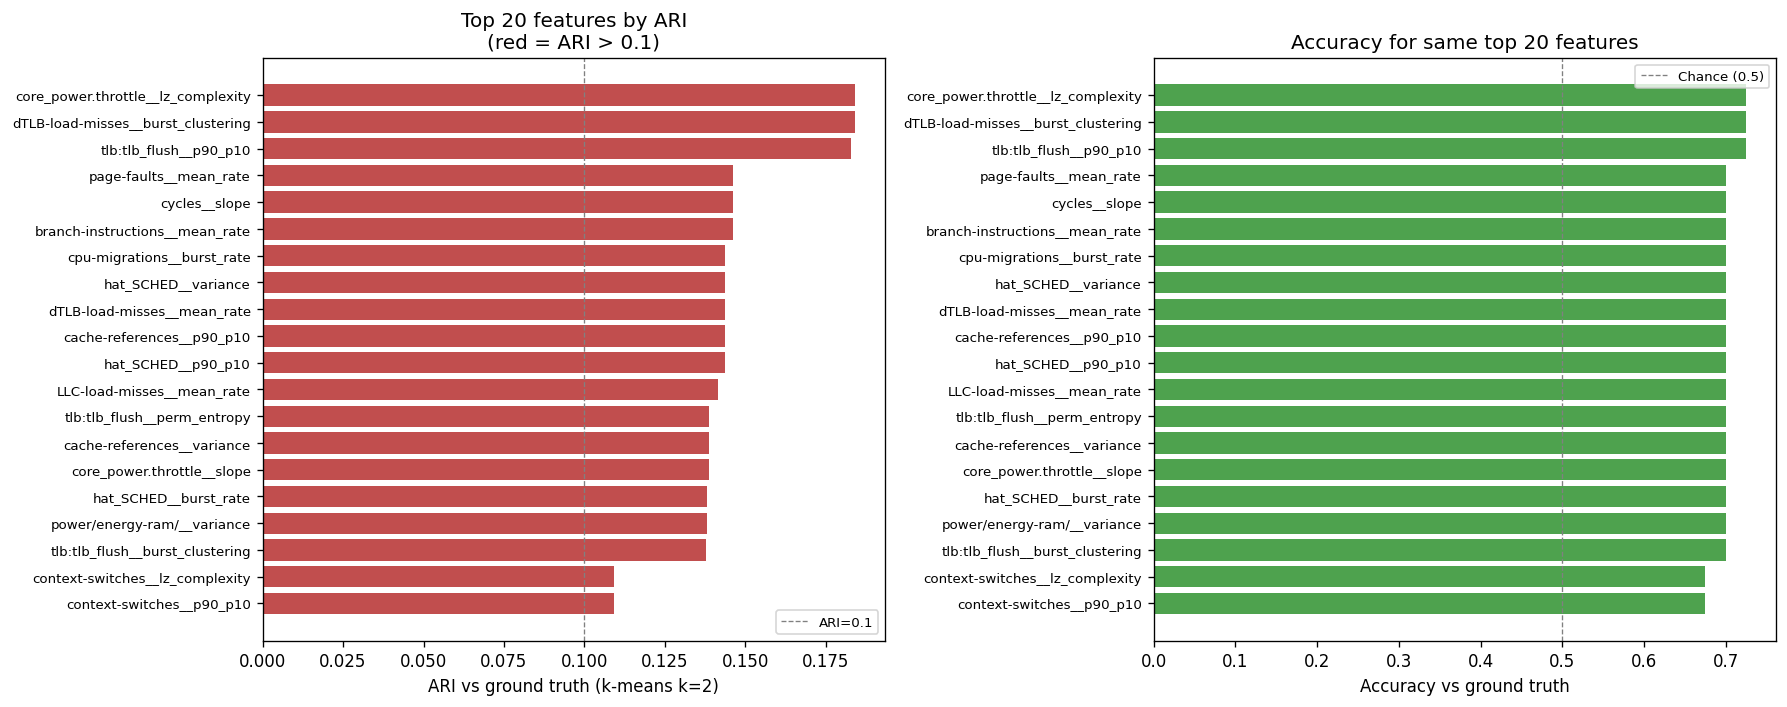

In [565]:
# Bar chart: top 20 features by ARI vs ground truth
top20 = clust_df.head(20)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: ARI
ax = axes[0]
colors = ['firebrick' if row.ari > 0.1 else 'steelblue' for _, row in top20.iterrows()]
ax.barh(range(len(top20)), top20.ari, color=colors, alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.feature, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.5)
ax.axvline(0.1, color='gray', lw=0.8, ls='--', label='ARI=0.1')
ax.set_xlabel('ARI vs ground truth (k-means k=2)')
ax.set_title('Top 20 features by ARI\n(red = ARI > 0.1)')
ax.legend(fontsize=8)

# Right: accuracy
ax = axes[1]
colors2 = ['forestgreen' if row.acc > 0.6 else 'salmon' for _, row in top20.iterrows()]
ax.barh(range(len(top20)), top20.acc, color=colors2, alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.feature, fontsize=8)
ax.invert_yaxis()
ax.axvline(0.5, color='gray', lw=0.8, ls='--', label='Chance (0.5)')
ax.set_xlabel('Accuracy vs ground truth')
ax.set_title('Accuracy for same top 20 features')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


------------

____________

_____________________

______________________________________________

## 8 — Multi-feature Kmeans clustering on top-K features

Fit a k=2 full-covariance GMM on the top-K features by composite rank.
The feature matrix is standardised before fitting (GMM is not scale-invariant).


In [566]:
TOP_K = 7  # adjust after inspecting ranking

top_features = ranking.head(TOP_K)['feature'].tolist()
X_top = X[top_features].values

# K-Means k=2 on top-K features
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_top)
km_labels = km.predict(X_top)

ari_km_main = adjusted_rand_score(y, km_labels)

# Align KMeans label 0/1 to neutral/emotional
acc_direct  = (km_labels == y).mean()
acc_flipped = (1 - km_labels == y).mean()
if acc_flipped > acc_direct:
    km_labels = 1 - km_labels
accuracy = (km_labels == y).mean()

print(f'K-Means (k=2) on top {TOP_K} features:')
print(f'  ARI:      {ari_km_main:.4f}')
print(f'  Accuracy vs ground truth: {accuracy:.1%}')
print(f'  Neutral correctly assigned:   {(km_labels[y==0] == 0).mean():.1%}')
print(f'  Emotional correctly assigned: {(km_labels[y==1] == 1).mean():.1%}')
print(f'\nFeatures: {top_features}')


K-Means (k=2) on top 7 features:
  ARI:      0.1880
  Accuracy vs ground truth: 72.5%
  Neutral correctly assigned:   100.0%
  Emotional correctly assigned: 45.0%

Features: ['core_power.throttle__lz_complexity', 'page-faults__mean_rate', 'tlb:tlb_flush__p90_p10', 'dTLB-load-misses__mean_rate', 'dTLB-load-misses__burst_clustering', 'hat_SCHED__p90_p10', 'cache-references__variance']


In [567]:
# ── Multi-feature: K-Means vs Spectral Clustering comparison ─────────────────
# Run both algorithms on the same top-K feature set and compare.

def _run_and_align(lbl, y):
    """Align cluster labels to ground truth and return ari, acc, aligned labels."""
    if (1 - lbl == y).mean() > (lbl == y).mean():
        lbl = 1 - lbl
    return adjusted_rand_score(y, lbl), (lbl == y).mean(), lbl

# --- K-Means k=2 (already run above, reuse km_labels) ---
ari_km_top  = ari_km_main
acc_km_top  = accuracy
lbl_km_top  = km_labels

# --- Spectral Clustering k=2 on top-K features ---
n_nbrs_top = min(15, len(X_top) - 1)
spec_top = SpectralClustering(
    n_clusters=2, affinity='nearest_neighbors',
    n_neighbors=n_nbrs_top, random_state=42,
    assign_labels='kmeans', n_init=10,
)
lbl_sc_top = spec_top.fit_predict(X_top)
ari_sc_top, acc_sc_top, lbl_sc_top = _run_and_align(lbl_sc_top, y)

# --- Summary table ---
print(f'Algorithm comparison on top {TOP_K} features:')
print(f'{"Algorithm":20s}  {"ARI":>8s}  {"Accuracy":>10s}')
print('-' * 44)
for name, ari, acc in [
    ('K-Means k=2',  ari_km_top, acc_km_top),
    ('Spectral k=2', ari_sc_top, acc_sc_top),
]:
    print(f'{name:20s}  {ari:8.4f}  {acc:10.1%}')

print(f'\nFeatures: {top_features}')


Algorithm comparison on top 7 features:
Algorithm                  ARI    Accuracy
--------------------------------------------
K-Means k=2             0.1880       72.5%
Spectral k=2            0.2305       75.0%

Features: ['core_power.throttle__lz_complexity', 'page-faults__mean_rate', 'tlb:tlb_flush__p90_p10', 'dTLB-load-misses__mean_rate', 'dTLB-load-misses__burst_clustering', 'hat_SCHED__p90_p10', 'cache-references__variance']


### K-sweep

Sweep K from 1 to N and plot ARI and accuracy as a function of the number of features.
A sharp peak at small K indicates the discriminative signal is concentrated in a few indicators.


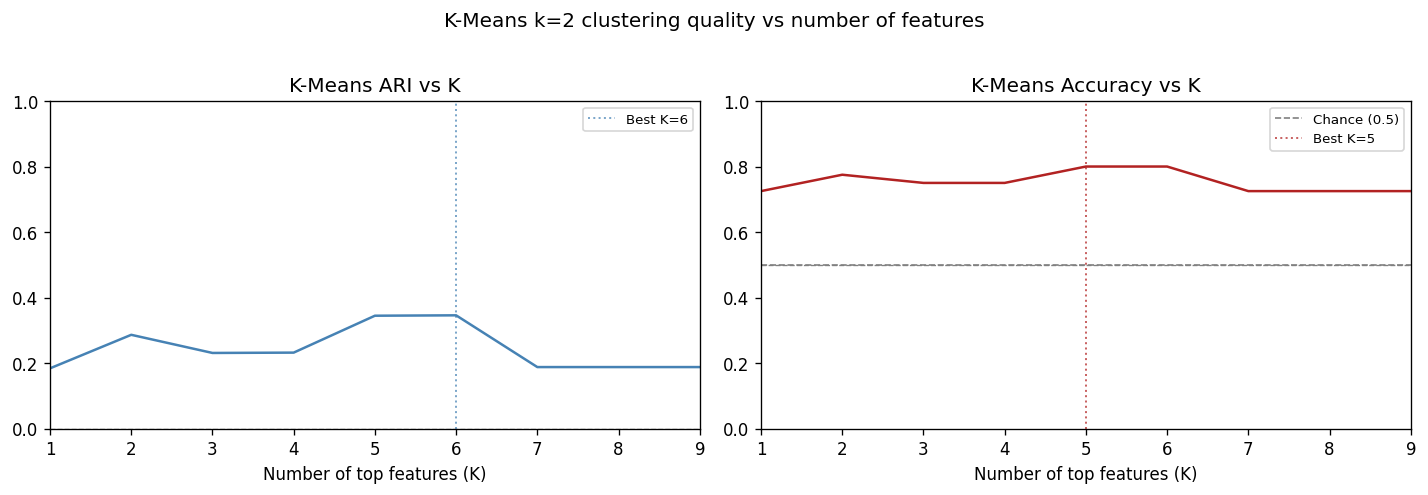

Best ARI = 0.3459 at K=6
Best Acc = 0.8000 at K=5


In [568]:
# Sweep K from 1 to N: how does K-Means clustering quality scale with number of features?
K_vals = list(range(1, min(10, 10)))

ari_vals, acc_vals = [], []

for k in K_vals:
    feats = ranking.head(k)['feature'].tolist()
    Xk = X[feats].values
    try:
        km_k = KMeans(n_clusters=2, random_state=42, n_init=5)
        lbl = km_k.fit_predict(Xk)
        ari_k = adjusted_rand_score(y, lbl)
        acc_k = max((lbl == y).mean(), (1 - lbl == y).mean())
        ari_vals.append(ari_k)
        acc_vals.append(acc_k)
    except Exception:
        ari_vals.append(np.nan)
        acc_vals.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title, color, hline in [
    (axes[0], ari_vals, 'K-Means ARI vs K',      'steelblue', 0.0),
    (axes[1], acc_vals, 'K-Means Accuracy vs K', 'firebrick', 0.5),
]:
    ax.plot(K_vals, vals, color=color, lw=1.5)
    ax.axhline(hline, color='gray', lw=0.8, ls='--')
    ax.set_ylim(0, 1)
    ax.set_xlim(min(K_vals), max(K_vals))
    ax.set_xlabel('Number of top features (K)')
    ax.set_title(title)

axes[1].axhline(0.5, color='gray', lw=1.0, ls='--', label='Chance (0.5)')
axes[1].legend(fontsize=8)

best_ari_k = K_vals[int(np.nanargmax(ari_vals))]
best_acc_k = K_vals[int(np.nanargmax(acc_vals))]
axes[0].axvline(best_ari_k, color='steelblue', lw=1.2, ls=':', alpha=0.7, label=f'Best K={best_ari_k}')
axes[1].axvline(best_acc_k, color='firebrick', lw=1.2, ls=':', alpha=0.7, label=f'Best K={best_acc_k}')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)

plt.suptitle('K-Means k=2 clustering quality vs number of features', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Best ARI = {max(v for v in ari_vals if not np.isnan(v)):.4f} at K={best_ari_k}')
print(f'Best Acc = {max(v for v in acc_vals if not np.isnan(v)):.4f} at K={best_acc_k}')


In [569]:
k_df = pd.DataFrame({
    'K':        K_vals,
    'ARI':      ari_vals,
    'Accuracy': acc_vals,
})
k_df_clean = k_df.dropna()

print('=== K-sweep summary statistics ===\n')
for metric in ['ARI', 'Accuracy']:
    vals = k_df_clean[metric].values
    ks   = k_df_clean['K'].values
    max_idx = np.argmax(vals)
    min_idx = np.argmin(vals)
    print(f'{metric}:')
    print(f'  Max  = {vals[max_idx]:.4f} at K = {ks[max_idx]}')
    print(f'  Min  = {vals[min_idx]:.4f} at K = {ks[min_idx]}')
    print(f'  Mean = {np.mean(vals):.4f}  Std = {np.std(vals):.4f}')
    print()

best_ari_k = int(k_df_clean.loc[k_df_clean['ARI'].idxmax(), 'K'])
best_acc_k = int(k_df_clean.loc[k_df_clean['Accuracy'].idxmax(), 'K'])
print(f'Best ARI at K = {best_ari_k}')
print(f'Best Accuracy at K = {best_acc_k}')


=== K-sweep summary statistics ===

ARI:
  Max  = 0.3459 at K = 6
  Min  = 0.1841 at K = 1
  Mean = 0.2431  Std = 0.0629

Accuracy:
  Max  = 0.8000 at K = 5
  Min  = 0.7250 at K = 1
  Mean = 0.7528  Std = 0.0299

Best ARI at K = 6
Best Accuracy at K = 5


## 9 — PCA visualisation of cluster structure

Project the top-K features onto 2 principal components. Three panels:
ground truth, GMM prediction, and misclassified points highlighted.


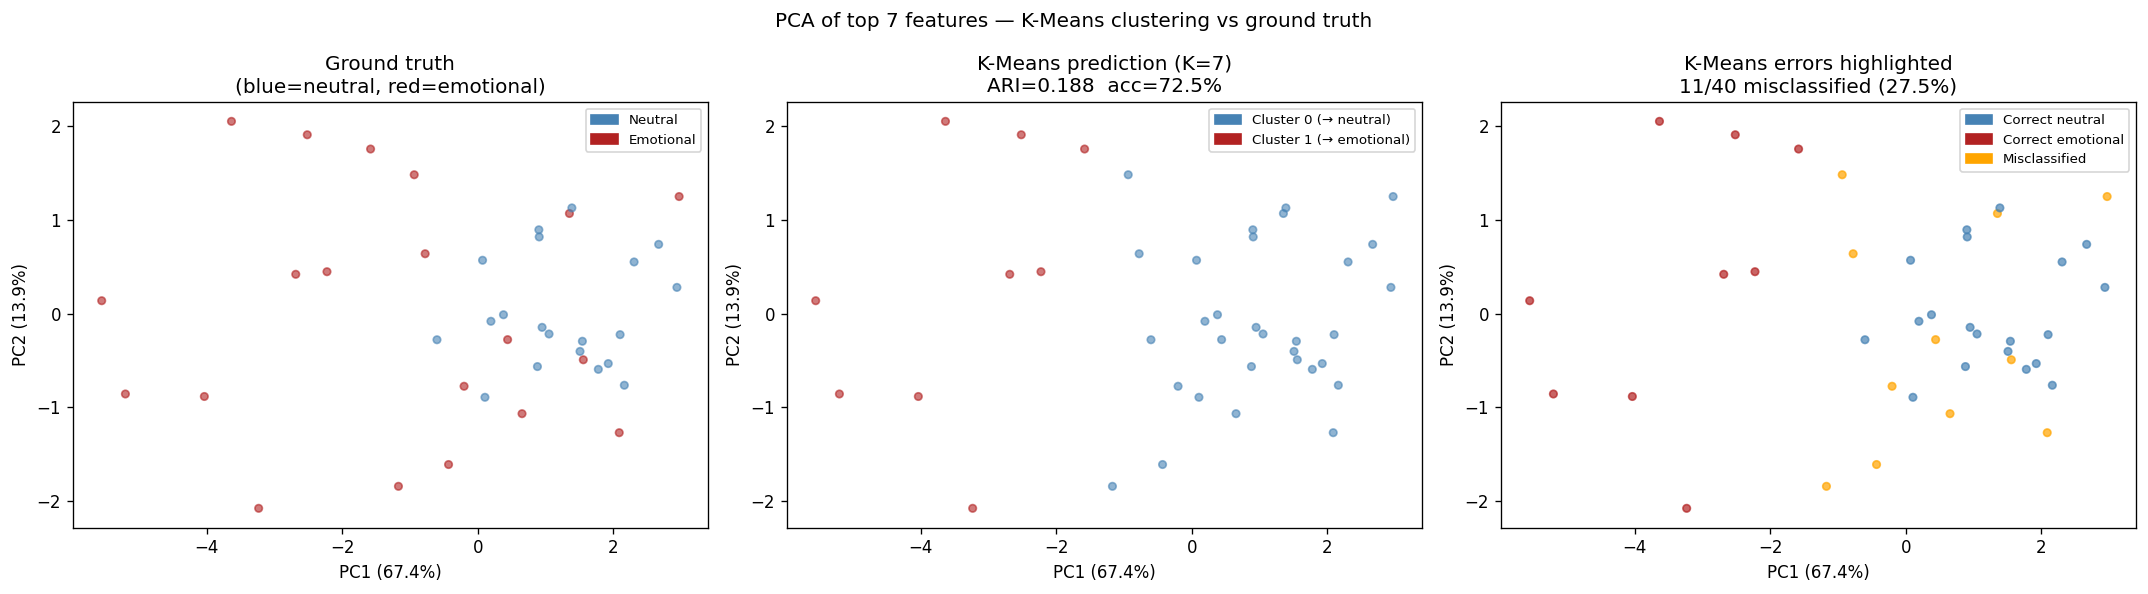

PCA explained variance: PC1=67.4%, PC2=13.9%


In [570]:
from matplotlib.patches import Patch

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X[top_features].values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: ground truth
ax = axes[0]
gt_colors = ['steelblue' if yi == 0 else 'firebrick' for yi in y]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=gt_colors, alpha=0.6, s=20)
ax.set_title('Ground truth\n(blue=neutral, red=emotional)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Neutral'),
                   Patch(color='firebrick', label='Emotional')], fontsize=8)

# Panel 2: K-Means prediction
ax = axes[1]
colors_pred = ['steelblue' if l == 0 else 'firebrick' for l in km_labels]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pred, alpha=0.6, s=20)
ax.set_title(f'K-Means prediction (K={TOP_K})\nARI={ari_km_main:.3f}  acc={accuracy:.1%}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Cluster 0 (→ neutral)'),
                   Patch(color='firebrick', label='Cluster 1 (→ emotional)')], fontsize=8)

# Panel 3: errors — where did K-Means go wrong?
ax = axes[2]
correct = km_labels == y
point_colors = []
for gi, yi, ci in zip(km_labels, y, correct):
    if ci:
        point_colors.append('steelblue' if yi == 0 else 'firebrick')
    else:
        point_colors.append('orange')
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, alpha=0.7, s=20)
n_errors = (~correct).sum()
ax.set_title(f'K-Means errors highlighted\n{n_errors}/{len(y)} misclassified ({n_errors/len(y):.1%})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Correct neutral'),
                   Patch(color='firebrick', label='Correct emotional'),
                   Patch(color='orange',    label='Misclassified')], fontsize=8)

plt.suptitle(f'PCA of top {TOP_K} features — K-Means clustering vs ground truth', fontsize=12)
plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')


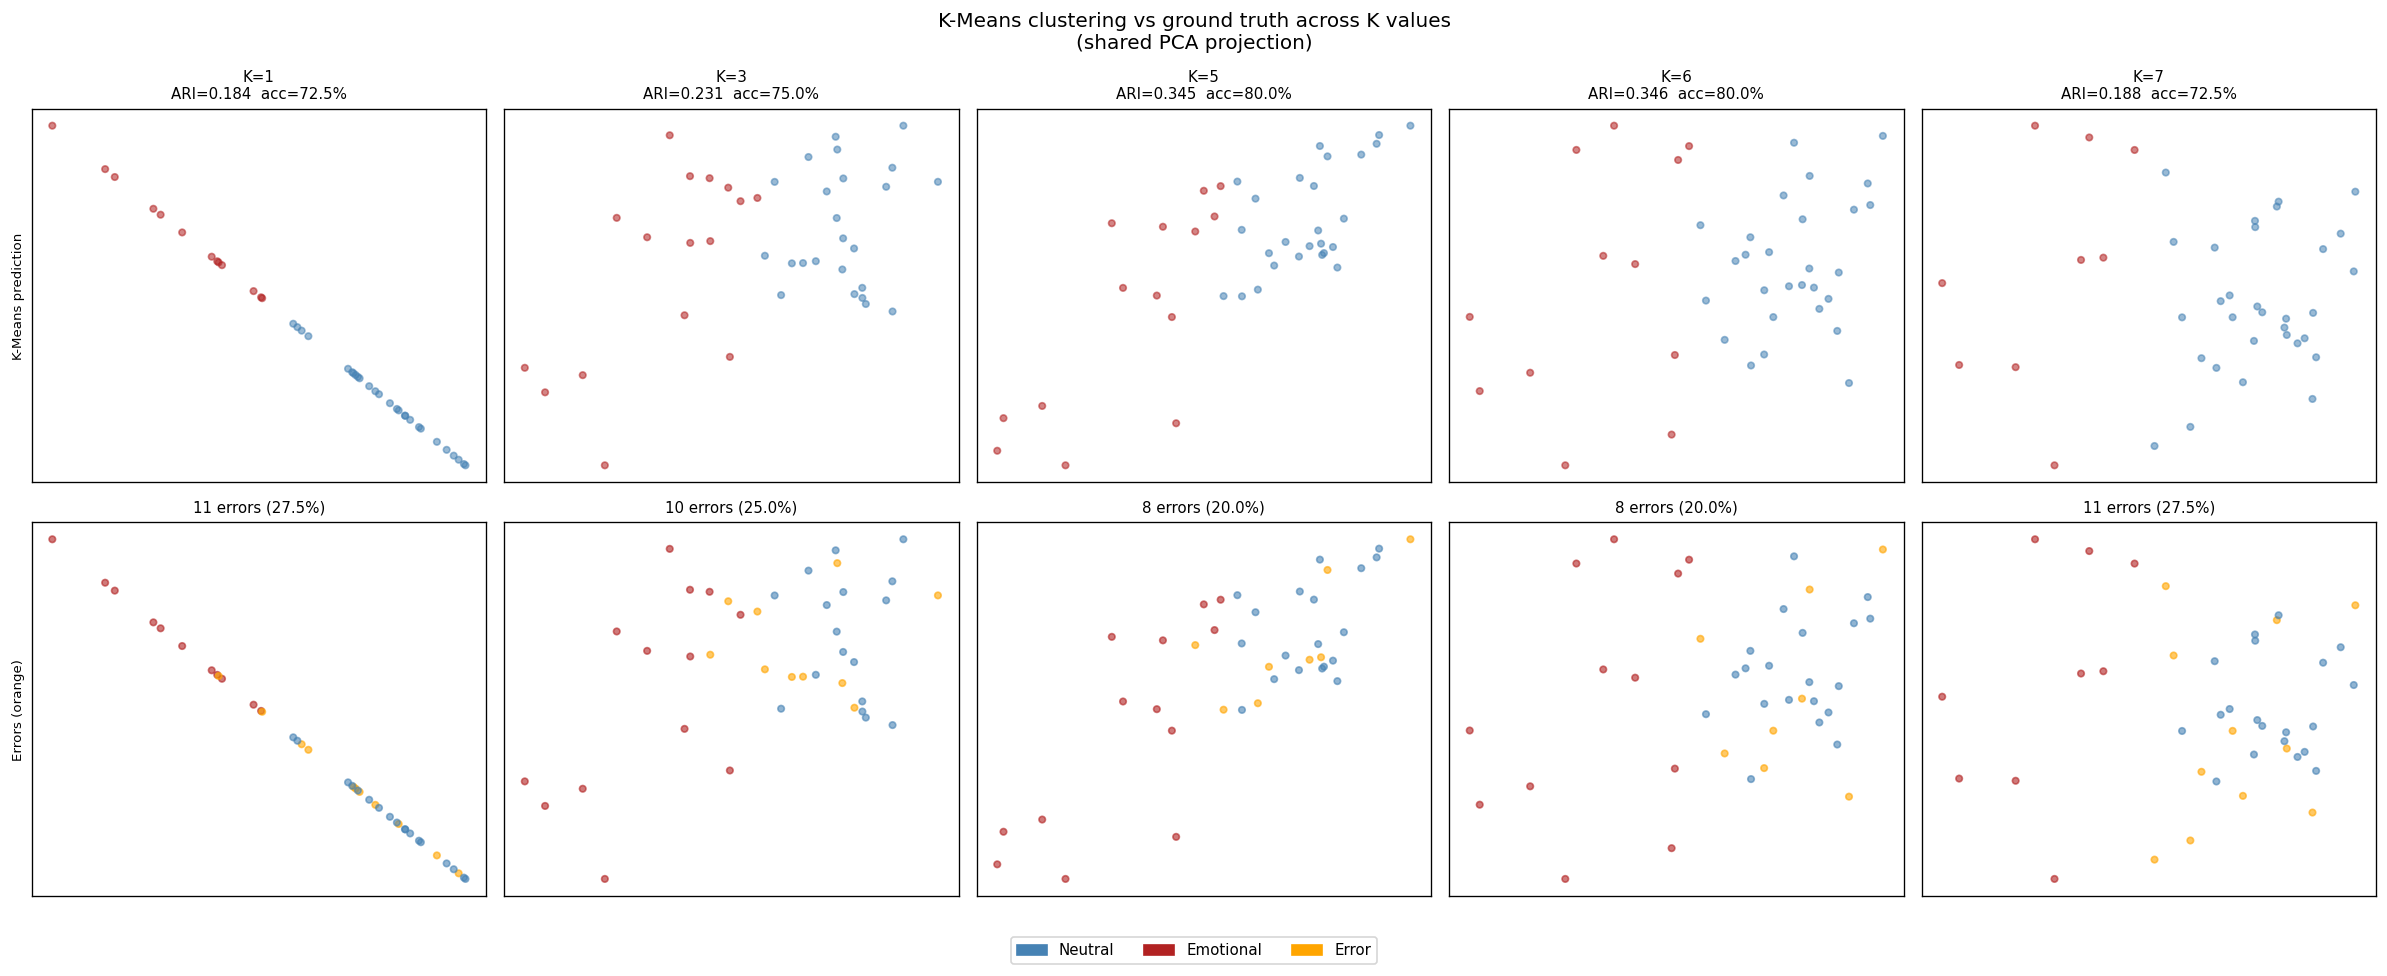

In [571]:
# ── PCA scatter: K-Means assignments vs ground truth for multiple K values ──
# Visualise how cluster separation evolves as we add more features.

Ks_to_plot = sorted({1, 3, 5, best_ari_k, best_acc_k, TOP_K})
Ks_to_plot = [k for k in Ks_to_plot if 1 <= k <= len(feat_cols)]

n_cols = len(Ks_to_plot)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

# PCA fit on the full top-K feature set for a stable projection across panels
_pca_ref = PCA(n_components=2, random_state=42)
_pca_ref.fit(X[ranking.head(max(Ks_to_plot))['feature'].tolist()].values)

for col_i, k in enumerate(Ks_to_plot):
    feats_k = ranking.head(k)['feature'].tolist()
    Xk = X[feats_k].values
    km_k = KMeans(n_clusters=2, random_state=42, n_init=10)
    lbl_k = km_k.fit_predict(Xk)
    # Align orientation
    if (1 - lbl_k == y).mean() > (lbl_k == y).mean():
        lbl_k = 1 - lbl_k
    ari_k = adjusted_rand_score(y, lbl_k)
    acc_k = (lbl_k == y).mean()

    # Project onto shared PCA space (pad with zeros if k < max_K)
    Xk_padded = np.zeros((len(Xk), max(Ks_to_plot)))
    Xk_padded[:, :k] = Xk
    coords = _pca_ref.transform(Xk_padded)

    # Top row: K-Means prediction coloured by predicted cluster
    ax_top = axes[0, col_i]
    pred_colors = ['steelblue' if l == 0 else 'firebrick' for l in lbl_k]
    ax_top.scatter(coords[:, 0], coords[:, 1], c=pred_colors, alpha=0.55, s=15)
    ax_top.set_title(f'K={k}\nARI={ari_k:.3f}  acc={acc_k:.1%}', fontsize=9)
    if col_i == 0:
        ax_top.set_ylabel('K-Means prediction', fontsize=8)
    ax_top.set_xticks([]); ax_top.set_yticks([])

    # Bottom row: errors highlighted
    ax_bot = axes[1, col_i]
    correct_k = lbl_k == y
    err_colors = []
    for gi, yi, ci in zip(lbl_k, y, correct_k):
        if ci:
            err_colors.append('steelblue' if yi == 0 else 'firebrick')
        else:
            err_colors.append('orange')
    ax_bot.scatter(coords[:, 0], coords[:, 1], c=err_colors, alpha=0.6, s=15)
    n_err = (~correct_k).sum()
    ax_bot.set_title(f'{n_err} errors ({n_err/len(y):.1%})', fontsize=9)
    if col_i == 0:
        ax_bot.set_ylabel('Errors (orange)', fontsize=8)
    ax_bot.set_xticks([]); ax_bot.set_yticks([])

from matplotlib.patches import Patch
leg_handles = [Patch(color='steelblue', label='Neutral'),
               Patch(color='firebrick', label='Emotional'),
               Patch(color='orange',    label='Error')]
fig.legend(handles=leg_handles, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('K-Means clustering vs ground truth across K values\n(shared PCA projection)',
             fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## 10 — Feature correlation matrix

Identify remaining redundancy among the top features after pruning.
Pairs with |r| > 0.9 carry overlapping information.


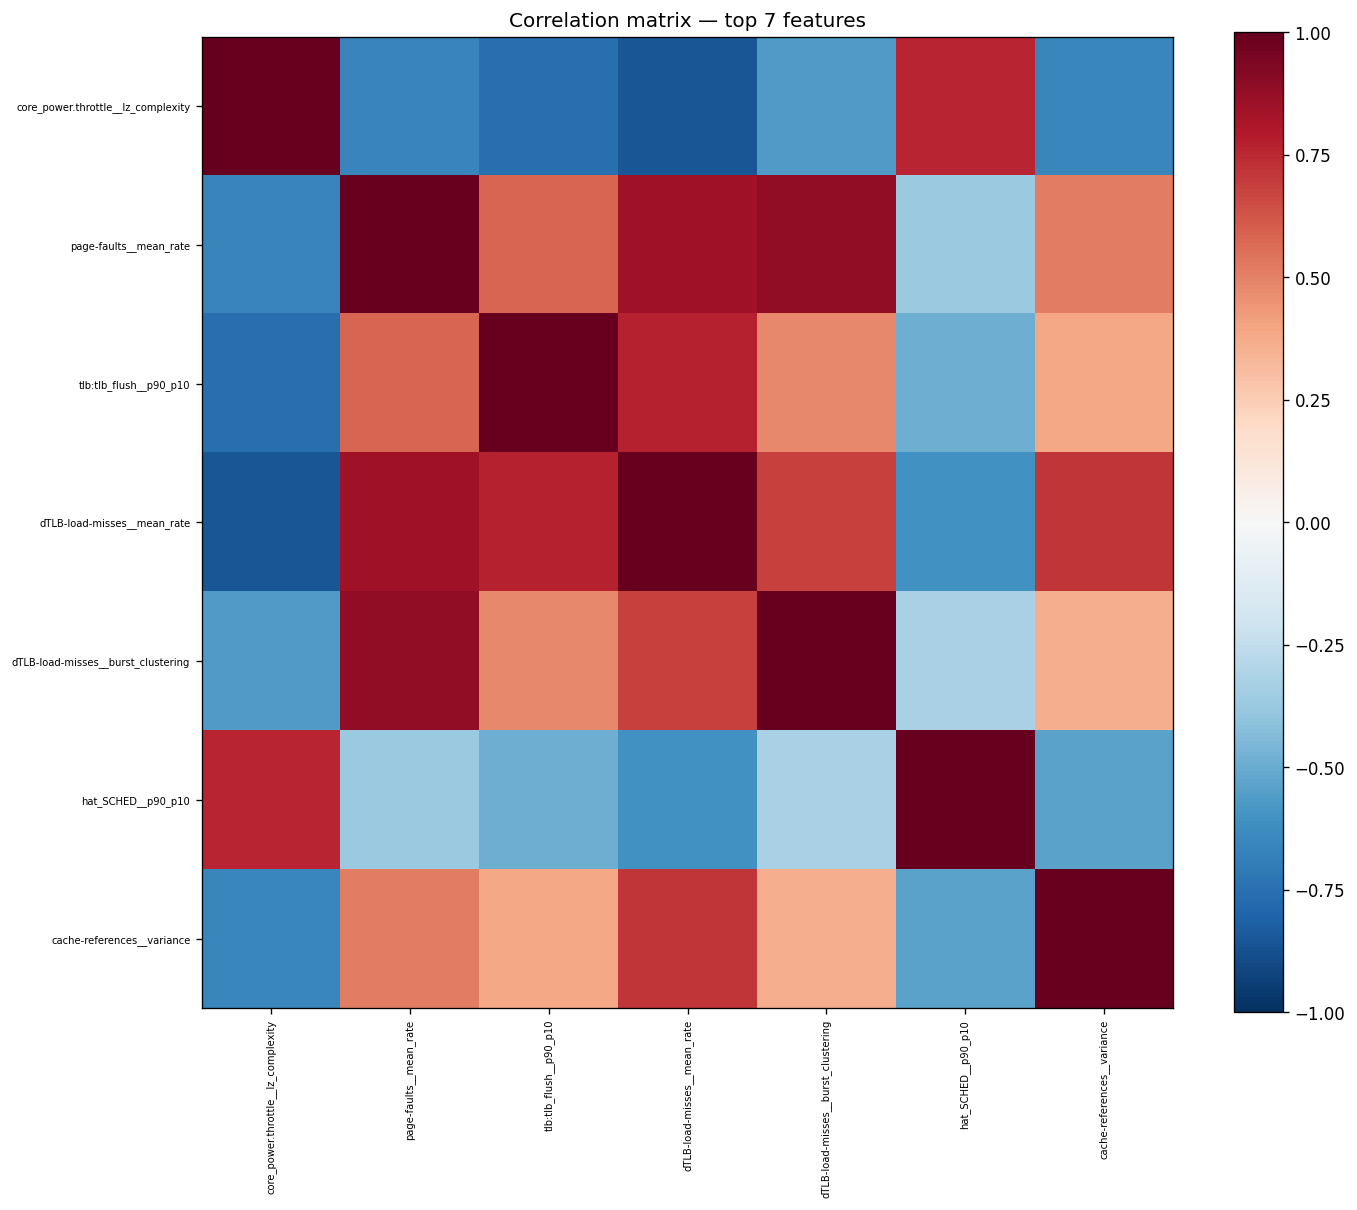

No highly correlated pairs among top features.


In [572]:
CORR_TOP = min(30, len(top_features))
corr = X[ranking.head(CORR_TOP)['feature'].tolist()].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(CORR_TOP))
ax.set_yticks(range(CORR_TOP))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.index, fontsize=6)
ax.set_title(f'Correlation matrix — top {CORR_TOP} features')
plt.tight_layout()
plt.show()

# Report highly correlated pairs
high_corr = []
cols = list(corr.columns)
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        if j <= i:
            continue
        r = corr.loc[a, b]
        if abs(r) > 0.9:
            high_corr.append({'feature_A': a, 'feature_B': b, 'r': r})
if high_corr:
    print(f'Highly correlated pairs (|r|>0.9): {len(high_corr)}')
    print(pd.DataFrame(high_corr).to_string(index=False, float_format='{:.3f}'.format))
else:
    print('No highly correlated pairs among top features.')

## 11 — Indicator structure audit

Before per-indicator clustering, verify the feature column structure is as expected.
Column names follow the pattern `<indicator>__<metric>`. There are three categories:
- **Named softirq / HAT indicators** (~20): `hat_BLOCK`, `hat_NET_RX`, `hat_TLB`, etc. — the meaningful ones
- **Perf hardware counters**: `cache-misses`, `LLC-load-misses`, `dTLB-load-misses`, etc.
- **Numeric IRQ lines** (`hat_0`, `hat_190`, ...): individual `/proc/interrupts` rows — not independent indicators, excluded from per-indicator analysis

Going forward, per-indicator clustering uses only the named/semantic indicators (`ind_map_named`).


In [573]:
# parse_feature: split 'indicator__metric' into its two parts
def parse_feature(fname):
    parts = fname.rsplit('__', 1)
    return (parts[0], parts[1]) if len(parts) == 2 else (fname, '')

METRIC_NAMES = ['mean_rate','variance','p90_p10','slope','spectral_entropy',
                'iat_cv','burst_rate','burst_clustering','lz_complexity','perm_entropy']

print('parse_feature defined.')


parse_feature defined.


In [574]:
METRIC_NAMES = ['mean_rate','variance','p90_p10','slope','spectral_entropy',
                'iat_cv','burst_rate','burst_clustering','lz_complexity','perm_entropy']

# Build indicator → list of metric columns mapping
# This includes EVERY unique indicator prefix in the feature matrix
from collections import defaultdict
ind_map_raw = defaultdict(list)
for col in feat_cols:
    indicator, metric = parse_feature(col)
    if metric in METRIC_NAMES:
        ind_map_raw[indicator].append(col)
ind_map_raw = dict(ind_map_raw)

print(f'Total indicators found in feature matrix: {len(ind_map_raw)}')
print()

# Categorise each indicator by type
import re

def classify_indicator(name):
    """Classify an indicator name into a category."""
    if re.fullmatch(r'hat_\d+', name):
        return 'numeric_irq'      # e.g. hat_190, hat_447 — raw /proc/interrupts rows
    elif name.startswith('hat_') and name[4:].isupper():
        return 'named_softirq'    # e.g. hat_HRTIMER, hat_LOC, hat_MCP
    elif name.startswith('hat_') and name[4:].isalpha():
        return 'named_softirq'    # e.g. hat_CAL
    elif name.startswith('hat_'):
        return 'hat_other'        # e.g. hat_LOC (mixed)
    elif name == 'cpu_freq_mean':
        return 'cpu_freq'
    else:
        return 'perf_counter'     # e.g. cache-misses, cycles, context-switches

category_counts = defaultdict(int)
for ind in ind_map_raw:
    category_counts[classify_indicator(ind)] += 1

print('=== Indicator categories ===')
for cat, n in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat:20s}: {n:4d} indicators')

print()
print('=== Named softirq / hat indicators (the ~20 we care about) ===')
named = {k: v for k, v in ind_map_raw.items()
         if classify_indicator(k) in ('named_softirq', 'hat_other', 'cpu_freq')}
for ind, cols in sorted(named.items()):
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    missing = [m for m in METRIC_NAMES if m not in metrics_present]
    flag = '  ← MISSING METRICS: ' + ', '.join(missing) if missing else ''
    print(f'  {ind:20s}: {len(cols):2d} metrics  [{', '.join(metrics_present)}]{flag}')

print()
print('=== Perf hardware/software counters ===')
perf = {k: v for k, v in ind_map_raw.items() if classify_indicator(k) == 'perf_counter'}
for ind, cols in sorted(perf.items()):
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    missing = [m for m in METRIC_NAMES if m not in metrics_present]
    flag = '  ← MISSING: ' + ', '.join(missing) if missing else ''
    print(f'  {ind:30s}: {len(cols):2d} metrics{flag}')

print()
print('=== Numeric IRQ indicators (first 20 shown) ===')
numeric = {k: v for k, v in ind_map_raw.items() if classify_indicator(k) == 'numeric_irq'}
for ind, cols in sorted(numeric.items(), key=lambda x: int(x[0].split('_')[1]))[:20]:
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    print(f'  {ind:15s}: {len(cols):2d} metrics  [{', '.join(metrics_present)}]')
print(f'  ... and {len(numeric)-20} more numeric IRQ indicators')

Total indicators found in feature matrix: 29

=== Indicator categories ===
  perf_counter        :   20 indicators
  named_softirq       :    8 indicators
  cpu_freq            :    1 indicators

=== Named softirq / hat indicators (the ~20 we care about) ===
  cpu_freq_mean       :  8 metrics  [burst_clustering, burst_rate, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy]  ← MISSING METRICS: variance, iat_cv
  hat_BLOCK           : 10 metrics  [burst_clustering, burst_rate, iat_cv, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy, variance]
  hat_IWI             :  5 metrics  [lz_complexity, perm_entropy, slope, spectral_entropy, variance]  ← MISSING METRICS: mean_rate, p90_p10, iat_cv, burst_rate, burst_clustering
  hat_NET_RX          :  9 metrics  [burst_clustering, burst_rate, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy, variance]  ← MISSING METRICS: iat_cv
  hat_RCU             :  9 metrics  [burst_clust

In [575]:
# Build the two indicator maps
NAMED_CATEGORIES = {'named_softirq', 'hat_other', 'cpu_freq', 'perf_counter'}

ind_map_named = {k: v for k, v in ind_map_raw.items()
                 if classify_indicator(k) in NAMED_CATEGORIES}
ind_map_all   = ind_map_raw  # full map including numeric IRQs

print(f'Named/semantic indicators: {len(ind_map_named)}')
print(f'All indicators (incl. numeric IRQs): {len(ind_map_all)}')
print()
print('Named indicators and their metric counts:')
for ind, cols in sorted(ind_map_named.items()):
    n_metrics = len(cols)
    metrics = sorted([parse_feature(c)[1] for c in cols])
    print(f'  {ind:30s}: {n_metrics:2d} metrics')

print()
print('NOTE: Expected 10 metrics each. If any show <10, check which ones are missing above.')
print('  iat_cv is intentionally NaN for PCIs (perf counters sampled at fixed interval).')
print('  If it is also missing for named softirqs (event-indicators), that is a bug.')

Named/semantic indicators: 29
All indicators (incl. numeric IRQs): 29

Named indicators and their metric counts:
  LLC-load-misses               :  9 metrics
  branch-instructions           :  9 metrics
  branch-misses                 :  9 metrics
  cache-misses                  :  4 metrics
  cache-references              :  7 metrics
  context-switches              :  7 metrics
  core_power.throttle           :  9 metrics
  cpu-clock                     :  7 metrics
  cpu-migrations                :  7 metrics
  cpu_freq_mean                 :  8 metrics
  cycles                        :  9 metrics
  dTLB-load-misses              :  9 metrics
  hat_BLOCK                     : 10 metrics
  hat_IWI                       :  5 metrics
  hat_NET_RX                    :  9 metrics
  hat_RCU                       :  9 metrics
  hat_SCHED                     :  9 metrics
  hat_TASKLET                   :  1 metrics
  hat_TIMER                     :  9 metrics
  hat_TLB                       

## 12 — Per-indicator × per-metric clustering

For every (indicator, metric) pair, cluster on that single scalar and score against ground truth.
This is the most interpretable output: it shows exactly which measurement of which indicator drives separation.

**Score interpretation:**
- High ARI + low p: statistically significant and geometrically separable — strongest evidence
- Low ARI + low p: statistically significant shift but distributions overlap too much to cluster cleanly
- High ARI + high p: geometric separation without a strong distributional shift (rare)
- Low ARI + high p: no signal


In [576]:

def cluster_and_score(x1d, y, indicator_name, n_init=10, random_state=42):
    """
    Cluster a single 1-D feature with KMeans (k=2) and Spectral Clustering (k=2),
    align predicted labels to ground truth, and return a results dict.

    Parameters
    ----------
    x1d            : (n, 1) float array — raw feature values
    y              : (n,)   int array   — ground truth (0=neutral, 1=emotional)
    indicator_name : str                — stored in the output dict
    n_init         : int                — KMeans restarts
    random_state   : int

    Returns
    -------
    dict with keys:
        indicator, n_samples,
        km_ari,  km_acc,  km_n_acc,  km_e_acc,
        sc_ari,  sc_acc
    """
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans, SpectralClustering
    from sklearn.metrics import adjusted_rand_score

    result = dict(indicator=indicator_name)

    # Drop NaN / Inf rows
    mask = np.isfinite(x1d).ravel()
    Xc = x1d[mask]
    yc = y[mask]
    result['n_samples'] = int(mask.sum())

    if mask.sum() < 10 or len(np.unique(yc)) < 2:
        for key in ('km_ari', 'km_acc', 'km_n_acc', 'km_e_acc',
                    'sc_ari', 'sc_acc'):
            result[key] = np.nan
        return result

    # Standardise
    sc_scaler = StandardScaler()
    Xs = sc_scaler.fit_transform(Xc)

    def _align_and_score(lbl, gt):
        """Flip labels if that improves accuracy, return ari, acc, n_acc, e_acc."""
        acc_d = (lbl == gt).mean()
        acc_f = (1 - lbl == gt).mean()
        if acc_f > acc_d:
            lbl = 1 - lbl
        ari   = adjusted_rand_score(gt, lbl)
        acc   = (lbl == gt).mean()
        n_acc = (lbl[gt == 0] == 0).mean() if (gt == 0).sum() > 0 else np.nan
        e_acc = (lbl[gt == 1] == 1).mean() if (gt == 1).sum() > 0 else np.nan
        return ari, acc, n_acc, e_acc

    # ── KMeans ───────────────────────────────────────────────────────
    try:
        km = KMeans(n_clusters=2, random_state=random_state, n_init=n_init)
        lbl_km = km.fit_predict(Xs)
        km_ari, km_acc, km_n_acc, km_e_acc = _align_and_score(lbl_km, yc)
        result.update(km_ari=km_ari, km_acc=km_acc,
                      km_n_acc=km_n_acc, km_e_acc=km_e_acc)
    except Exception:
        result.update(km_ari=np.nan, km_acc=np.nan,
                      km_n_acc=np.nan, km_e_acc=np.nan)

    # ── Spectral Clustering ──────────────────────────────────────────
    try:
        n_nbrs = min(10, mask.sum() - 1)
        spec = SpectralClustering(
            n_clusters=2,
            affinity='nearest_neighbors',
            n_neighbors=n_nbrs,
            random_state=random_state,
            assign_labels='kmeans',
            n_init=n_init,
        )
        lbl_sc = spec.fit_predict(Xs)
        sc_ari, sc_acc, _, _ = _align_and_score(lbl_sc, yc)
        result.update(sc_ari=sc_ari, sc_acc=sc_acc)
    except Exception:
        result.update(sc_ari=np.nan, sc_acc=np.nan)

    return result

print('cluster_and_score defined (KMeans + Spectral).')


cluster_and_score defined (KMeans + Spectral).


In [577]:
print('Running per-indicator × per-metric clustering...')
print(f'This will process {sum(len(v) for v in ind_map_named.values())} (indicator, metric) cells')
print()

per_cell_results = []
for indicator, cols in sorted(ind_map_named.items()):
    indicator_results = []
    for col in cols:
        _, metric = parse_feature(col)
        x1d = X_raw[[col]].values.astype(float)
        res = cluster_and_score(x1d, y, indicator)
        res['metric']  = metric
        res['feature'] = col
        per_cell_results.append(res)
        indicator_results.append((metric, res.get('km_ari', np.nan), res.get('km_acc', np.nan)))
    
    # Print a one-line summary per indicator showing all metrics
    print(f'  {indicator:30s}:')
    for metric, ari, acc in sorted(indicator_results, key=lambda x: -(x[1] or -1)):
        if np.isnan(ari):
            print(f'    {metric:20s}: SKIP')
        else:
            bar = '█' * int(max(0, ari) * 15)
            print(f'    {metric:20s}: ARI={ari:.3f}  acc={acc:.1%}  {bar}')

cell_df = pd.DataFrame(per_cell_results)
print(f'\nTotal cells computed: {len(cell_df)}')


Running per-indicator × per-metric clustering...
This will process 220 (indicator, metric) cells

  LLC-load-misses               :
    mean_rate           : ARI=0.142  acc=70.0%  ██
    variance            : ARI=0.066  acc=65.0%  
    slope               : ARI=-0.003  acc=57.5%  
    lz_complexity       : ARI=-0.009  acc=55.0%  
    p90_p10             : ARI=-0.014  acc=55.0%  
    burst_rate          : ARI=-0.015  acc=55.0%  
    spectral_entropy    : ARI=-0.024  acc=52.5%  
    burst_clustering    : ARI=-0.025  acc=50.0%  
    perm_entropy        : ARI=0.000  acc=52.5%  
  branch-instructions           :
    mean_rate           : ARI=0.146  acc=70.0%  ██
    burst_clustering    : ARI=0.038  acc=62.5%  
    slope               : ARI=0.017  acc=60.0%  
    burst_rate          : ARI=0.005  acc=57.5%  
    spectral_entropy    : ARI=-0.003  acc=57.5%  
    variance            : ARI=-0.014  acc=55.0%  
    lz_complexity       : ARI=-0.022  acc=50.0%  
    p90_p10             : ARI=-0.024 

In [578]:
# Merge with MWU statistics from §7
cell_df = cell_df.merge(
    mwu_df[['feature','p','effect_r','direction']],
    on='feature', how='left'
)

cell_df_sorted = cell_df.sort_values('km_ari', ascending=False).reset_index(drop=True)

print('=== Top 30 (indicator, metric) cells by K-Means ARI ===')
print('Interpretation: sorted by how well a SINGLE metric on a SINGLE indicator')
print('clusters the trials into their correct neutral/emotional groups.')
print()
show = ['indicator','metric','km_ari','km_acc','km_n_acc','km_e_acc','sc_ari','sc_acc','p','effect_r','direction']
print(cell_df_sorted.head(30)[show].to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== Bottom 10 (indicator, metric) cells — near-zero ARI ===')
cell_bottom = cell_df_sorted[cell_df_sorted.km_ari.notna()].tail(10)
print(cell_bottom[show].to_string(index=False, float_format='{:.4f}'.format))

cell_df_sorted.to_csv(RESULTS_DIR / 'per_indicator_per_metric.csv', index=False)
print(f'\nSaved → {RESULTS_DIR}/per_indicator_per_metric.csv')


=== Top 30 (indicator, metric) cells by K-Means ARI ===
Interpretation: sorted by how well a SINGLE metric on a SINGLE indicator
clusters the trials into their correct neutral/emotional groups.

           indicator           metric  km_ari  km_acc  km_n_acc  km_e_acc  sc_ari  sc_acc      p  effect_r direction
    dTLB-load-misses burst_clustering  0.1841  0.7250    0.9000    0.5500  0.1009  0.6750 0.0133   -0.4600        ↓E
 core_power.throttle    lz_complexity  0.1841  0.7250    0.9000    0.5500  0.1820  0.7250 0.0016    0.5850        ↑E
       tlb:tlb_flush          p90_p10  0.1829  0.7250    0.8500    0.6000  0.1399  0.7000 0.0044   -0.5075        ↓E
         page-faults        mean_rate  0.1460  0.7000    1.0000    0.4000  0.1829  0.7250 0.0005   -0.6500        ↓E
              cycles            slope  0.1460  0.7000    1.0000    0.4000  0.0661  0.6500 0.0601    0.3500        ↑E
 branch-instructions        mean_rate  0.1460  0.7000    1.0000    0.4000  0.0379  0.6250 0.0239   -0.4

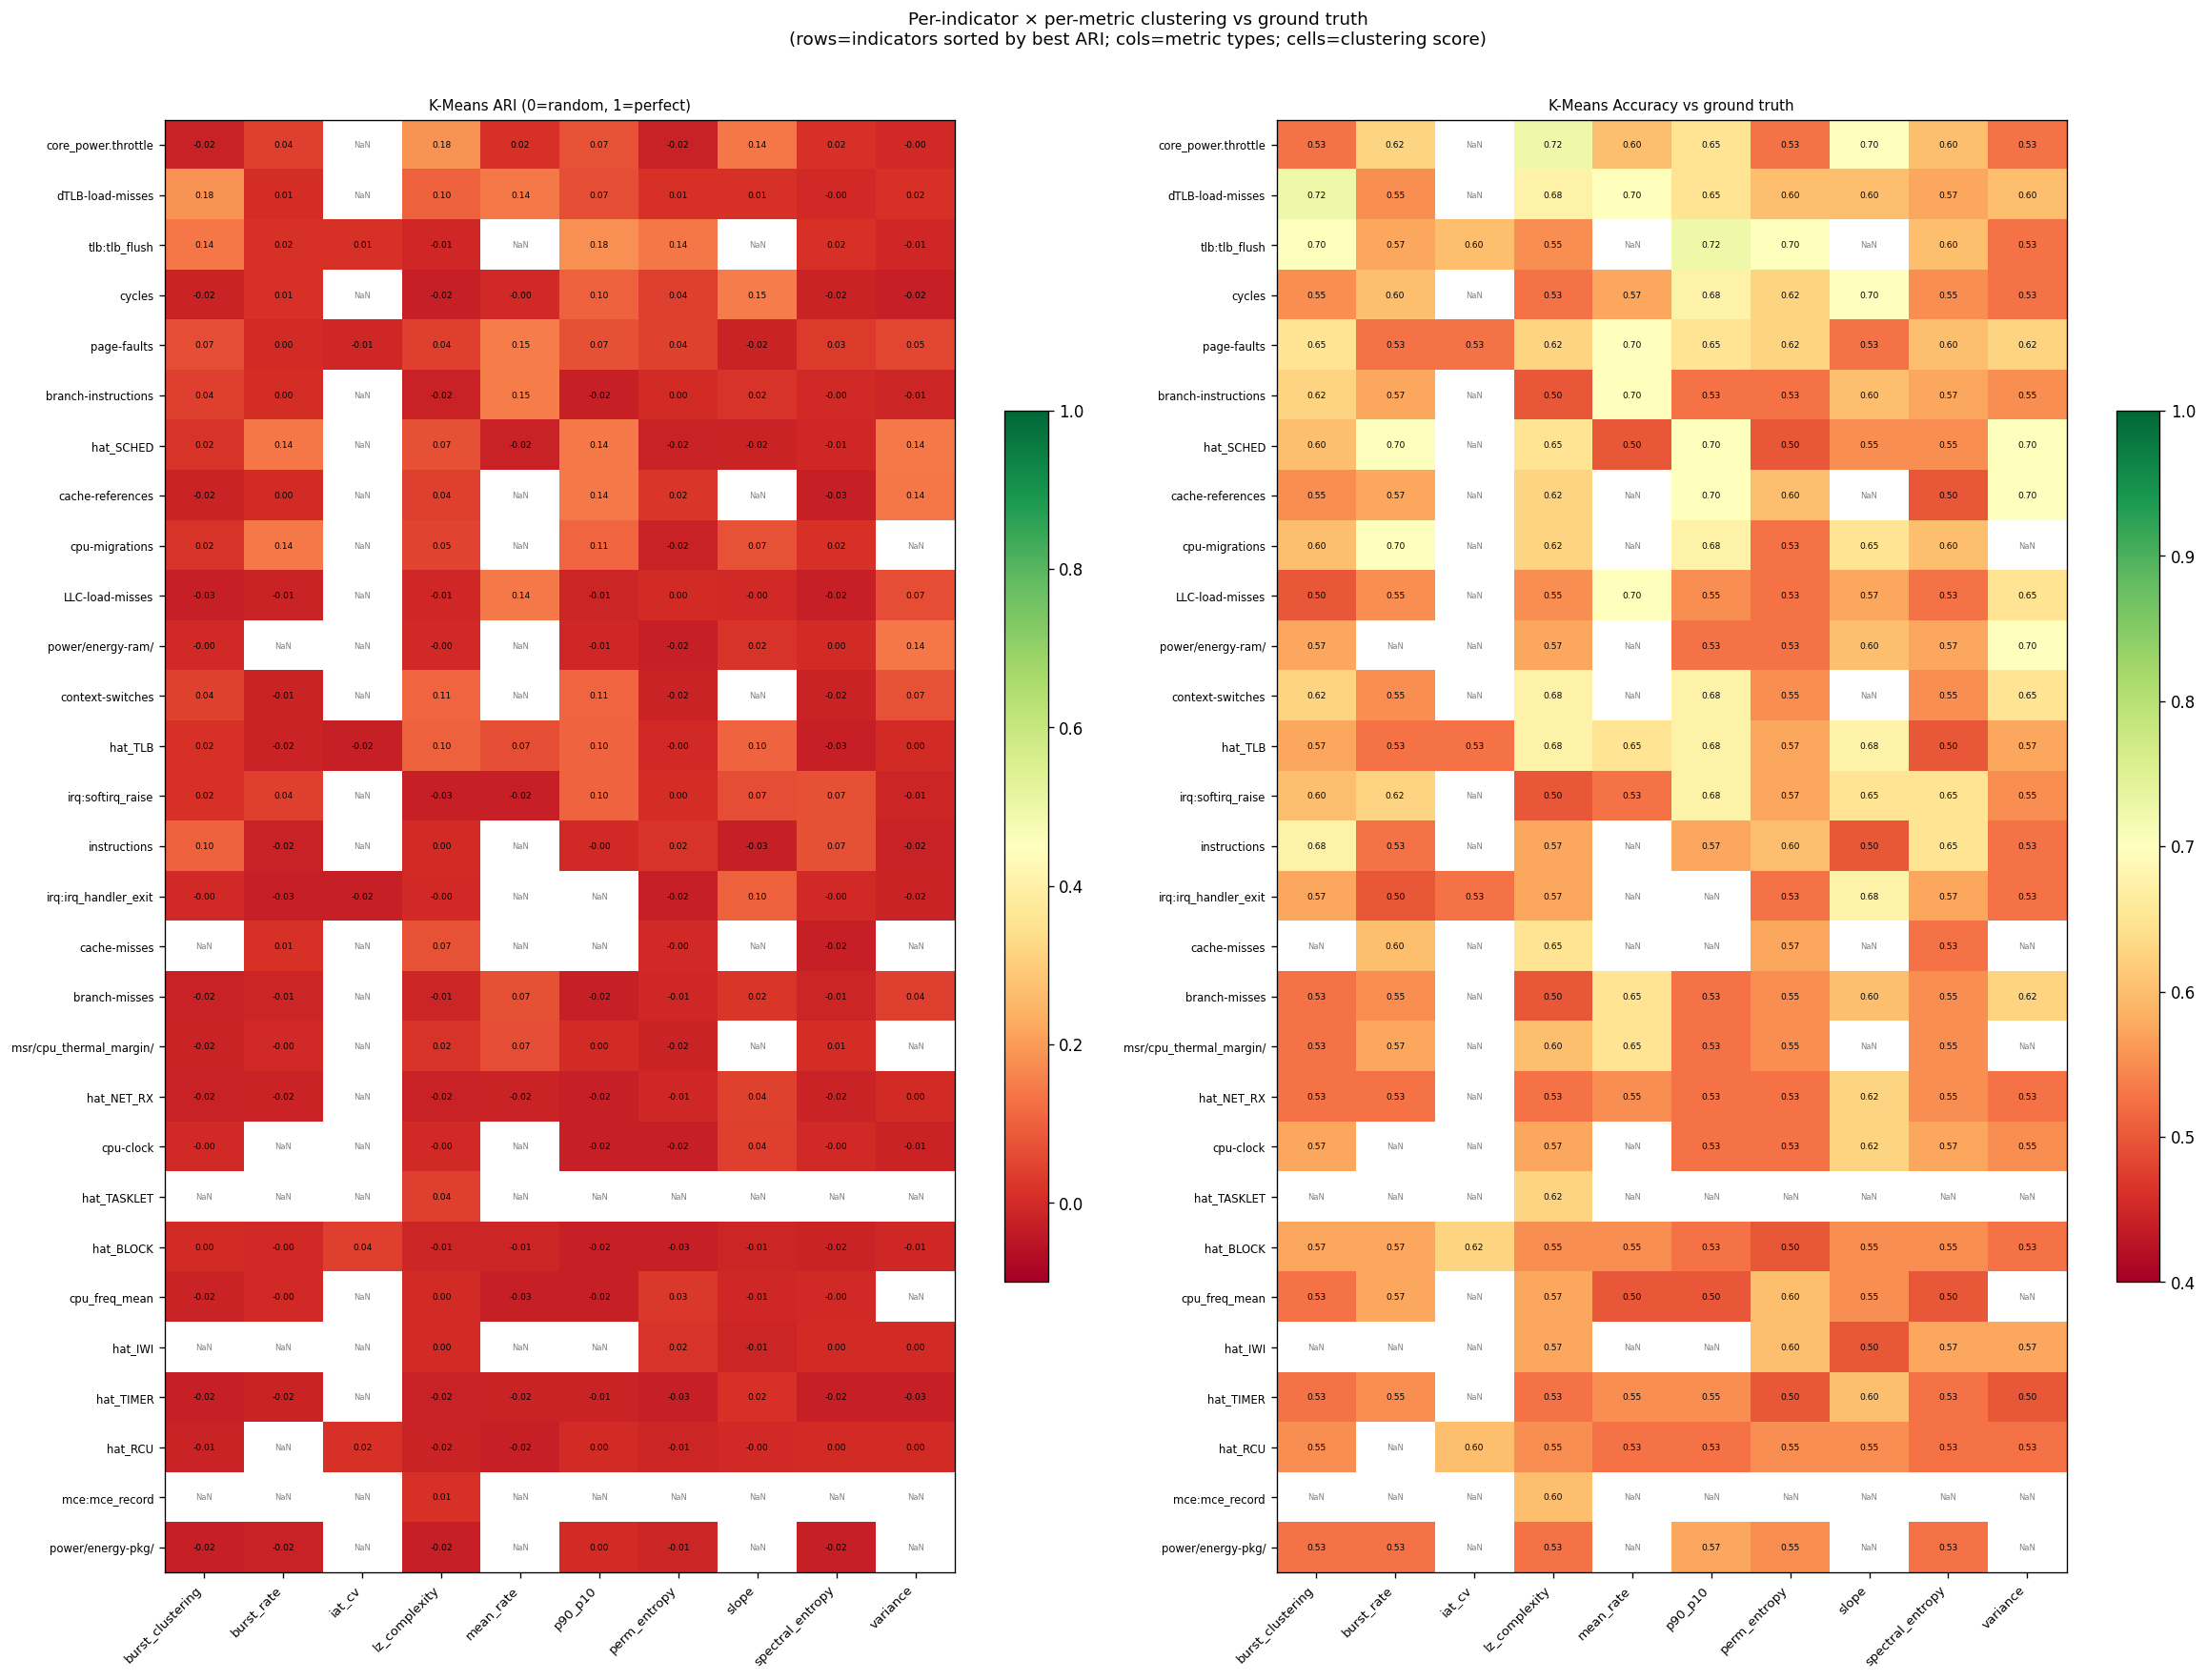

In [579]:
# ── Heatmap: indicators × metrics, coloured by K-Means ARI ──
# Use named indicators only
all_named_inds = sorted(ind_map_named.keys())

# Sort rows by best single-metric ARI (most discriminative indicator on top)
best_ari_per_ind = (
    cell_df.groupby('indicator')['km_ari']
    .max().sort_values(ascending=False)
)
ordered_inds = best_ari_per_ind.index.tolist()

pivot_ari = cell_df.pivot_table(
    index='indicator', columns='metric', values='km_ari', aggfunc='first'
).reindex(index=ordered_inds)

pivot_acc = cell_df.pivot_table(
    index='indicator', columns='metric', values='km_acc', aggfunc='first'
).reindex(index=ordered_inds)

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(ordered_inds) * 0.5)))

for ax, pivot, title, vmin, vmax, cmap in [
    (axes[0], pivot_ari, 'K-Means ARI (0=random, 1=perfect)',   -0.1, 1.0, 'RdYlGn'),
    (axes[1], pivot_acc, 'K-Means Accuracy vs ground truth',     0.4,  1.0, 'RdYlGn'),
]:
    im = ax.imshow(pivot.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.6)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(title, fontsize=9)
    # Annotate each cell
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=5.5, color='black')
            else:
                ax.text(j, i, 'NaN', ha='center', va='center',
                        fontsize=5, color='gray')

plt.suptitle(
    'Per-indicator × per-metric clustering vs ground truth\n'
    '(rows=indicators sorted by best ARI; cols=metric types; cells=clustering score)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()


## 13 — Confusion matrices for top (indicator, metric) pairs

For the top cells by K-Means ARI, show the full 2×2 confusion matrix.
A perfect result has zeros on the off-diagonal. Asymmetry reveals which condition is harder to assign.


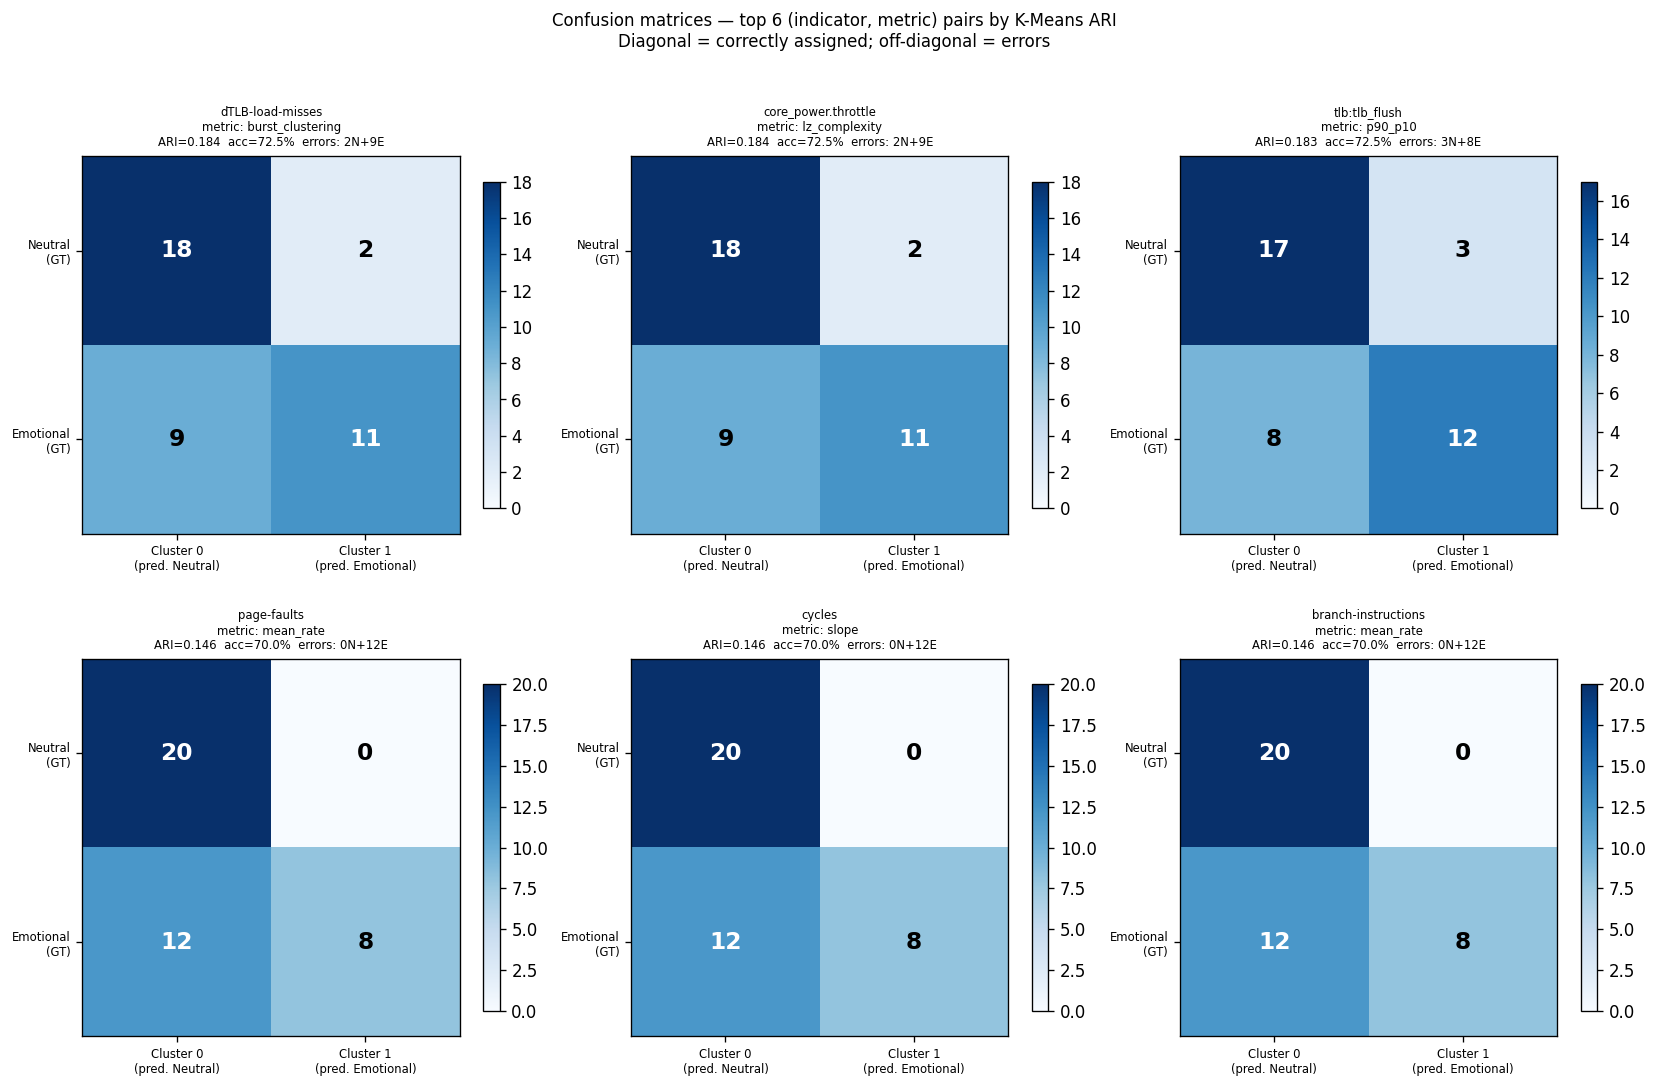

Zero off-diagonal = perfect separation.


In [580]:
TOP_CM = 6
top_cells = cell_df_sorted.dropna(subset=['km_ari']).head(TOP_CM)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, (_, row) in enumerate(top_cells.iterrows()):
    ax = axes[i]
    col = row['feature']

    x1d = X_raw[[col]].values.astype(float)
    mask = np.isfinite(x1d).ravel()
    Xc = x1d[mask]; yc = y[mask]

    sc = StandardScaler()
    Xs = sc.fit_transform(Xc)
    km_m = KMeans(n_clusters=2, random_state=42, n_init=10)
    lbl = km_m.fit_predict(Xs)

    # Align orientation
    if (1 - lbl == yc).mean() > (lbl == yc).mean():
        lbl = 1 - lbl

    cm = confusion_matrix(yc, lbl)
    # Rows: true label (0=neutral, 1=emotional); Cols: predicted cluster
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Cluster 0\n(pred. Neutral)', 'Cluster 1\n(pred. Emotional)'], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neutral\n(GT)', 'Emotional\n(GT)'], fontsize=7)

    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r, c] > cm.max() * 0.5 else 'black')

    acc = (lbl == yc).mean()
    n_err = cm[0, 1]  # neutral assigned to emotional cluster
    e_err = cm[1, 0]  # emotional assigned to neutral cluster
    ax.set_title(
        f'{row["indicator"]}\nmetric: {row["metric"]}\n'
        f'ARI={row["km_ari"]:.3f}  acc={acc:.1%}  '
        f'errors: {n_err}N+{e_err}E',
        fontsize=7
    )

plt.suptitle(f'Confusion matrices — top {TOP_CM} (indicator, metric) pairs by K-Means ARI\n'
             'Diagonal = correctly assigned; off-diagonal = errors',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()
print('Zero off-diagonal = perfect separation.')


## 14 — Final results table

All (indicator, metric) pairs ranked by K-Means ARI, split by length-sensitivity.

**Length-sensitive** metrics (flagged when `LENGTH_CONFOUNDED=True`): `variance`, `p90_p10`,
`lz_complexity`, `perm_entropy` — these may detect prompt duration rather than emotional content.
Safe metrics (`mean_rate`, `burst_rate`, `slope`, `spectral_entropy`, `iat_cv`) are reported separately.


In [581]:
summary = ranking.copy()
summary['indicator'] = summary.feature.apply(lambda f: parse_feature(f)[0])
summary['metric']    = summary.feature.apply(lambda f: parse_feature(f)[1])

# Flag if length-confounded: metrics NOT normalised by duration
non_normalised = ['variance', 'p90_p10', 'lz_complexity', 'perm_entropy']
summary['length_sensitive'] = summary.metric.isin(non_normalised) & LENGTH_CONFOUNDED

final_cols = ['composite_rank','indicator','metric','p','effect_r','direction',
              'ari','acc','purity','length_sensitive']
print('=== Final metric ranking (top 40) ===')
print(summary.head(40)[final_cols].to_string(index=False, float_format='{:.4f}'.format))


=== Final metric ranking (top 40) ===
 composite_rank               indicator           metric      p  effect_r direction    ari    acc  purity  length_sensitive
         2.7500     core_power.throttle    lz_complexity 0.0016    0.5850        ↑E 0.1841 0.7250  0.7564             False
         3.0000             page-faults        mean_rate 0.0005   -0.6500        ↓E 0.1460 0.7000  0.8125             False
         4.5000           tlb:tlb_flush          p90_p10 0.0044   -0.5075        ↓E 0.1829 0.7250  0.7400             False
         5.5000        dTLB-load-misses        mean_rate 0.0008   -0.6200        ↓E 0.1435 0.7000  0.7667             False
         8.7500        dTLB-load-misses burst_clustering 0.0133   -0.4600        ↓E 0.1841 0.7250  0.7564             False
        10.0000               hat_SCHED          p90_p10 0.0084    0.4900        ↑E 0.1435 0.7000  0.7667             False
        11.0000        cache-references         variance 0.0071   -0.5000        ↓E 0.1388 0.7

In [582]:
final = cell_df_sorted[[
    'indicator','metric','feature',
    'km_ari','km_acc','km_n_acc','km_e_acc',
    'sc_ari','sc_acc',
    'p','effect_r','direction','n_samples'
]].copy()

non_normalised = ['variance', 'p90_p10', 'lz_complexity', 'perm_entropy']
final['length_sensitive'] = final.metric.isin(non_normalised) & LENGTH_CONFOUNDED

# Print split by length-sensitivity
safe    = final[~final.length_sensitive].dropna(subset=['km_ari'])
suspect = final[final.length_sensitive].dropna(subset=['km_ari'])

print('=== TOP 20 SAFE metrics (not length-sensitive), sorted by K-Means ARI ===')
print('These are the strongest findings not confounded by prompt duration.')
print()
print(safe.head(20)[['indicator','metric','km_ari','sc_ari','km_acc','p','effect_r','direction']]
      .to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== TOP 20 LENGTH-SENSITIVE metrics (interpret with caution) ===')
print('These may be detecting prompt length rather than emotional content.')
print()
print(suspect.head(20)[['indicator','metric','km_ari','sc_ari','km_acc','p','effect_r','direction']]
      .to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== KEY FINDINGS (safe metrics, ARI > 0.05 in BOTH KMeans and Spectral) ===')
key = safe[(safe.km_ari > 0.05) & (safe.sc_ari > 0.05)].head(10)
for _, r in key.iterrows():
    print(f'  {r.indicator:30s} × {r.metric:20s}:  '
          f'KM={r.km_ari:.3f}  SC={r.sc_ari:.3f}  '
          f'acc={r.km_acc:.1%}  p={r.p:.2e}  {r.direction}')


=== TOP 20 SAFE metrics (not length-sensitive), sorted by K-Means ARI ===
These are the strongest findings not confounded by prompt duration.

          indicator           metric  km_ari  sc_ari  km_acc      p  effect_r direction
   dTLB-load-misses burst_clustering  0.1841  0.1009  0.7250 0.0133   -0.4600        ↓E
core_power.throttle    lz_complexity  0.1841  0.1820  0.7250 0.0016    0.5850        ↑E
      tlb:tlb_flush          p90_p10  0.1829  0.1399  0.7250 0.0044   -0.5075        ↓E
        page-faults        mean_rate  0.1460  0.1829  0.7000 0.0005   -0.6500        ↓E
             cycles            slope  0.1460  0.0661  0.7000 0.0601    0.3500        ↑E
branch-instructions        mean_rate  0.1460  0.0379  0.7000 0.0239   -0.4200        ↓E
          hat_SCHED          p90_p10  0.1435  0.0995  0.7000 0.0084    0.4900        ↑E
          hat_SCHED         variance  0.1435  0.0379  0.7000 0.0256    0.4150        ↑E
   dTLB-load-misses        mean_rate  0.1435  0.1381  0.7000 0.00

# 15 — Test set evaluation

Out-of-sample validation on a held-out test set collected in a separate session.

A KMeans model trained on each training feature is applied directly to the test set.
To guard against elapsed_ms differences between sessions, an `elapsed_ms` residualisation
step is applied: a linear regression fit on training data predicts each feature from
`elapsed_ms`, and test features are replaced with their residuals. Both raw and
residualised results are reported.


In [583]:

# ══════════════════════════════════════════════════════════════════════
# TEST SET EVALUATION — CLtestE + CLtestN
# 1-feature KMeans for top-10 safe features; visualise top-3 by ARI+acc
# ══════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression as _LR
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from matplotlib.patches import Patch

_node   = 'clemsonc6420'
_ddir   = BASE_DIR / 'data' / _node

df_test = pd.concat([pd.read_csv(_ddir / 'CLtestE.csv'),
                     pd.read_csv(_ddir / 'CLtestN.csv')], ignore_index=True)
y_test  = (df_test['condition'] == 'emotional').astype(int).values

print(f'Test set: {len(df_test)} trials  '
      f'(neutral={(df_test.condition=="neutral").sum()}, '
      f'emotional={(df_test.condition=="emotional").sum()})')
print(f'Test elapsed_ms:     mean={df_test.elapsed_ms.mean():.0f}  '
      f'median={df_test.elapsed_ms.median():.0f}')
print(f'Training elapsed_ms: mean={df_all.elapsed_ms.mean():.0f}  '
      f'median={df_all.elapsed_ms.median():.0f}')

# ── Build raw test feature matrix — only columns present in BOTH sets ─
avail_feat_cols = [c for c in feat_cols if c in df_test.columns]
missing_cols    = [c for c in feat_cols if c not in df_test.columns]
print(f'\nFeature columns: {len(avail_feat_cols)} available, '
      f'{len(missing_cols)} missing from test data (dropped)')

train_medians = X_raw[avail_feat_cols].median()
test_raw = df_test[avail_feat_cols].copy().fillna(train_medians)

# ── Residualise elapsed_ms (training coefficients applied to test) ────
print('\nFitting elapsed_ms residualisation on training data…')
elapsed_train = df_all[['elapsed_ms']].values.astype(float)
elapsed_test  = df_test[['elapsed_ms']].values.astype(float)

X_raw_resid    = X_raw[avail_feat_cols].copy()
test_raw_resid = test_raw.copy()

for _col in avail_feat_cols:
    yr_  = X_raw[_col].values.astype(float)
    msk  = np.isfinite(yr_) & np.isfinite(elapsed_train.ravel())
    if msk.sum() < 10:
        continue
    _reg = _LR().fit(elapsed_train[msk], yr_[msk])
    X_raw_resid[_col]    = yr_ - _reg.predict(elapsed_train)
    test_raw_resid[_col] = test_raw[_col].values - _reg.predict(elapsed_test)

print('Done.')

# ── Top-10 safe features (from available cols, not length-confounded) ─
safe_avail_cols = [c for c in avail_feat_cols
                   if c.split('__', 1)[-1] not in LENGTH_CONFOUNDED_METRICS]
_safe_ranking   = ranking[ranking['feature'].isin(safe_avail_cols)].copy()
top10_safe      = _safe_ranking.head(10)['feature'].tolist()

print(f'\nTop-10 safe features (available in test):')
for _f in top10_safe:
    print(f'  {_f}')

# ══════════════════════════════════════════════════════════════════════
# Evaluate each feature individually (1-feat KMeans)
# ══════════════════════════════════════════════════════════════════════
def _eval_1feat(feat_name, train_df, test_df, y_tr, y_te, n_init=20):
    sc   = StandardScaler()
    Xtr_ = sc.fit_transform(train_df[[feat_name]].fillna(0))
    Xte_ = sc.transform(test_df[[feat_name]].fillna(0))

    km_ = KMeans(n_clusters=2, random_state=42, n_init=n_init)
    km_.fit(Xtr_)
    lbl_tr_ = km_.predict(Xtr_)
    flip = (1 - lbl_tr_ == y_tr).mean() > (lbl_tr_ == y_tr).mean()

    lbl_te_ = km_.predict(Xte_)
    if flip:
        lbl_te_ = 1 - lbl_te_

    ari_   = adjusted_rand_score(y_te, lbl_te_)
    acc_   = (lbl_te_ == y_te).mean()
    n_acc_ = (lbl_te_[y_te == 0] == 0).mean() if (y_te == 0).sum() > 0 else np.nan
    e_acc_ = (lbl_te_[y_te == 1] == 1).mean() if (y_te == 1).sum() > 0 else np.nan

    pca_tr_ = np.column_stack([Xtr_, np.zeros(len(Xtr_))])
    pca_te_ = np.column_stack([Xte_, np.zeros(len(Xte_))])

    return dict(feat=feat_name, ari=ari_, acc=acc_,
                n_acc=n_acc_, e_acc=e_acc_, lbl_te=lbl_te_,
                pca_tr=pca_tr_, pca_te=pca_te_, flip=flip)

# Run both views (safe raw + residualised) for each feature
X_raw_avail = X_raw[avail_feat_cols]

print('\n' + '─'*72)
print(f'{"Feature":<42}  {"ARI":>6}  {"acc":>6}  {"N-acc":>6}  {"E-acc":>6}  view')
print('─'*72)

all_results = []
for _f in top10_safe:
    for _view, _tr, _te in [('safe',  X_raw_avail,  test_raw),
                             ('resid', X_raw_resid,  test_raw_resid)]:
        r = _eval_1feat(_f, _tr, _te, y, y_test)
        r['view'] = _view
        all_results.append(r)
        print(f'{_f:<42}  {r["ari"]:6.3f}  {r["acc"]:6.1%}  '
              f'{r["n_acc"]:6.1%}  {r["e_acc"]:6.1%}  {_view}')

# ══════════════════════════════════════════════════════════════════════
# Pick top-3 to visualise (by ARI desc, then acc desc)
# ══════════════════════════════════════════════════════════════════════
import pandas as _pd2
res_df = _pd2.DataFrame([{k: v for k, v in r.items()
                           if k not in ('lbl_te', 'pca_tr', 'pca_te')}
                          for r in all_results])

res_df_sorted = res_df.sort_values(['ari', 'acc'], ascending=False).reset_index(drop=True)
top3_vis = res_df_sorted.head(3)

print('\nTop-3 to visualise:')
print(top3_vis[['feat', 'view', 'ari', 'acc', 'n_acc', 'e_acc']].to_string(index=False))

top3_res = []
for _, row_ in top3_vis.iterrows():
    for r in all_results:
        if r['feat'] == row_['feat'] and r['view'] == row_['view']:
            top3_res.append(r)
            break


FileNotFoundError: [Errno 2] No such file or directory: '/Users/rsalvi/Desktop/mccviahat/data/clemsonc6420/CLtestE.csv'

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZATION — top-6 results: one self-contained figure per pair
# Each figure: left = 1-D strip plot, right = confusion matrix
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

C_NEUTRAL   = '#4878CF'
C_EMOTIONAL = '#D65F5F'
C_MISS_N = '#E67E22'   # orange — misclassified neutral (predicted emotional)
C_MISS_E = '#8E44AD' 

rng = np.random.default_rng(42)

for col_i, r in enumerate(top3_res):

    indicator, metric = r['feat'].split('__', 1)
    indicator_short   = indicator.replace('irq:', '').replace('hat_', '')
    view_tag          = 'elapsed-residualised' if r['view'] == 'resid' else 'raw'

    # ── Scaled feature values ────────────────────────────────────────
    _tr_df = X_raw_resid if r['view'] == 'resid' else X_raw
    _te_df = test_raw_resid if r['view'] == 'resid' else test_raw

    sc_ = StandardScaler().fit(_tr_df[[r['feat']]].fillna(0))
    tr_ = sc_.transform(_tr_df[[r['feat']]].fillna(0)).ravel()
    te_ = sc_.transform(_te_df[[r['feat']]].fillna(0)).ravel()

    tr_n = tr_[y == 0];        tr_e = tr_[y == 1]
    te_n = te_[y_test == 0];   te_e = te_[y_test == 1]

    te_miss_mask = (r['lbl_te'] != y_test)

    # ── Figure ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=(13, 4.5),
        gridspec_kw={'width_ratios': [2.2, 1], 'wspace': 0.32}
    )

    # ════════════════════════════════════════════════════════════════
    # LEFT: 1-D strip plot — single axis, colour encodes condition
    # Neutral and emotional points share the same vertical space;
    # train and test are separated into two Y rows.
    # ════════════════════════════════════════════════════════════════
    ax = axes[0]

    HALF_TRAIN = 0.30   # jitter half-width for training row
    HALF_TEST  = 0.22   # jitter half-width for test row
    GAP        = 0.18   # gap between train and test rows
    Y_TRAIN    = 0.0    # centre of training row
    Y_TEST     = -(HALF_TRAIN + GAP + HALF_TEST)  # centre of test row

    # ── Training row ─────────────────────────────────────────────────
    jtr_n = rng.uniform(Y_TRAIN - HALF_TRAIN, Y_TRAIN + HALF_TRAIN, size=len(tr_n))
    jtr_e = rng.uniform(Y_TRAIN - HALF_TRAIN, Y_TRAIN + HALF_TRAIN, size=len(tr_e))

    ax.scatter(tr_n, jtr_n, color=C_NEUTRAL,   alpha=0.62, s=16, linewidths=0)
    ax.scatter(tr_e, jtr_e, color=C_EMOTIONAL, alpha=0.62, s=16, linewidths=0)

    # ── Test row ──────────────────────────────────────────────────────
    jte_n = rng.uniform(Y_TEST - HALF_TEST, Y_TEST + HALF_TEST, size=len(te_n))
    jte_e = rng.uniform(Y_TEST - HALF_TEST, Y_TEST + HALF_TEST, size=len(te_e))

    correct_n = ~te_miss_mask[y_test == 0]
    correct_e = ~te_miss_mask[y_test == 1]
    wrong_n   =  te_miss_mask[y_test == 0]
    wrong_e   =  te_miss_mask[y_test == 1]

    if correct_n.any():
        ax.scatter(te_n[correct_n], jte_n[correct_n],
                   color=C_NEUTRAL,   s=55, marker='D',
                   edgecolors='white', linewidths=0.7, zorder=5)
    if correct_e.any():
        ax.scatter(te_e[correct_e], jte_e[correct_e],
                   color=C_EMOTIONAL, s=55, marker='D',
                   edgecolors='white', linewidths=0.7, zorder=5)
    if wrong_n.any():
        ax.scatter(te_n[wrong_n], jte_n[wrong_n],
                   color=C_MISS_N, s=70, marker='D',
                   edgecolors='#333333', linewidths=0.9, zorder=6)
    if wrong_e.any():
        ax.scatter(te_e[wrong_e], jte_e[wrong_e],
                   color=C_MISS_E, s=70, marker='D',
                   edgecolors='#333333', linewidths=0.9, zorder=6)

    # Divider between train and test rows
    y_div = (Y_TRAIN - HALF_TRAIN + Y_TEST + HALF_TEST) / 2
    ax.axhline(y_div, color='#bbbbbb', lw=0.9, ls='--', zorder=1)

    # Row labels on the left
    ax.text(ax.get_xlim()[0] if hasattr(ax,'_cachedRenderer') else -4,
            Y_TRAIN, 'train', va='center', ha='right',
            color='#666666', fontsize=8, style='italic')
    ax.text(-4, Y_TEST, 'test', va='center', ha='right',
            color='#666666', fontsize=8, style='italic')

    ax.set_xlabel('Scaled feature value', fontsize=10)
    ax.set_yticks([])
    margin = HALF_TRAIN + GAP + HALF_TEST + 0.15
    ax.set_ylim(Y_TEST - HALF_TEST - 0.15, Y_TRAIN + HALF_TRAIN + 0.15)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)

    n_err = int(te_miss_mask.sum())
    n_tot = len(y_test)
    ax.set_title(
        f'{indicator_short}  ×  {metric}   [{view_tag}]\n'
        f'ARI = {r["ari"]:.3f}   acc = {r["acc"]:.0%}   '
        f'N-recall = {r["n_acc"]:.0%}   E-recall = {r["e_acc"]:.0%}',
        fontsize=10, pad=8
    )

    leg_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_NEUTRAL,
               markersize=7, alpha=0.9, label='Train neutral'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_EMOTIONAL,
               markersize=7, alpha=0.9, label='Train emotional'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_NEUTRAL,
               markersize=6, markeredgecolor='white', label='Test neutral ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_EMOTIONAL,
               markersize=6, markeredgecolor='white', label='Test emotional ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_N,
               markersize=6, markeredgecolor='#333333', label='Neutral misclassified ✗'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_E,
               markersize=6, markeredgecolor='#333333', label='Emotional misclassified ✗'),
    ]
    ax.legend(handles=leg_handles, fontsize=7.5, loc='lower right',
              ncol=2, framealpha=0.85, edgecolor='#cccccc',
              handletextpad=0.4, columnspacing=0.8)

    # ════════════════════════════════════════════════════════════════
    # RIGHT: Confusion matrix — no coloured borders
    # ════════════════════════════════════════════════════════════════
    ax_cm = axes[1]

    cm_mat  = confusion_matrix(y_test, r['lbl_te'])
    n_total = cm_mat.sum()
    vmax_cm = max(cm_mat.max(), 1)

    ax_cm.imshow(cm_mat, cmap='Blues', vmin=0, vmax=vmax_cm, aspect='equal')

    for ri_ in range(2):
        for ci_ in range(2):
            val  = cm_mat[ri_, ci_]
            pct  = val / n_total * 100
            dark = val > vmax_cm * 0.55
            fg   = 'white' if dark else '#1a1a1a'
            ax_cm.text(ci_, ri_ - 0.10, str(val),
                       ha='center', va='center',
                       fontsize=20, fontweight='bold', color=fg)
            ax_cm.text(ci_, ri_ + 0.25, f'{pct:.0f}%',
                       ha='center', va='center',
                       fontsize=9, color=fg)

    ax_cm.set_xticks([0, 1])
    ax_cm.set_xticklabels(['Pred\nNeutral', 'Pred\nEmotional'], fontsize=9)
    ax_cm.set_yticks([0, 1])
    ax_cm.set_yticklabels(['True\nNeutral', 'True\nEmotional'], fontsize=9)
    ax_cm.tick_params(length=0)
    ax_cm.set_xlabel(
        f'{n_err} error{"s" if n_err != 1 else ""} / {n_total} trials',
        fontsize=9, labelpad=6
    )
    ax_cm.set_title('Confusion matrix', fontsize=10, pad=8)

    
    plt.show()
    print(f'[{col_i+1}/{len(top3_res)}]  {indicator_short} × {metric}  '
          f'({view_tag})  →  ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  '
          f'errors={n_err}/{n_total}')

NameError: name 'top3_res' is not defined

### hat_BLOCK features — test set deep-dive

`hat_BLOCK` was the dominant training feature but collapsed on the test set (session instability).
This section shows strip plots and confusion matrices for all hat_BLOCK metrics, both raw and
elapsed_ms-residualised, to characterise the collapse.


In [ ]:

# ══════════════════════════════════════════════════════════════════════
# hat_BLOCK features — test set strip plots + confusion matrices
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

block_feats = [c for c in avail_feat_cols if c.startswith('hat_BLOCK__')]
print(f'hat_BLOCK features in test: {block_feats}')

block_results = []
for _f in block_feats:
    for _view, _tr, _te in [('safe',  X_raw_avail,  test_raw),
                             ('resid', X_raw_resid,  test_raw_resid)]:
        r = _eval_1feat(_f, _tr, _te, y, y_test)
        r['view'] = _view
        block_results.append(r)

# Sort by ARI desc
block_results.sort(key=lambda x: -x['ari'])

for col_i, r in enumerate(block_results):
    indicator, metric = r['feat'].split('__', 1)
    indicator_short   = indicator.replace('hat_', '')
    view_tag          = 'elapsed-residualised' if r['view'] == 'resid' else 'raw'

    _tr_df = X_raw_resid if r['view'] == 'resid' else X_raw_avail
    _te_df = test_raw_resid if r['view'] == 'resid' else test_raw

    sc_ = StandardScaler().fit(_tr_df[[r['feat']]].fillna(0))
    tr_ = sc_.transform(_tr_df[[r['feat']]].fillna(0)).ravel()
    te_ = sc_.transform(_te_df[[r['feat']]].fillna(0)).ravel()

    tr_n = tr_[y == 0];        tr_e = tr_[y == 1]
    te_n = te_[y_test == 0];   te_e = te_[y_test == 1]
    te_miss_mask = (r['lbl_te'] != y_test)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                             gridspec_kw={'width_ratios': [2.2, 1], 'wspace': 0.32})

    ax = axes[0]
    HALF_TRAIN, HALF_TEST, GAP = 0.28, 0.20, 0.16
    Y_TRAIN, Y_TEST = 0.0, -(HALF_TRAIN + GAP + HALF_TEST)

    _rng = np.random.default_rng(42 + col_i)
    ax.scatter(tr_n, _rng.uniform(Y_TRAIN-HALF_TRAIN, Y_TRAIN+HALF_TRAIN, len(tr_n)),
               color=C_NEUTRAL, alpha=0.55, s=14, linewidths=0)
    ax.scatter(tr_e, _rng.uniform(Y_TRAIN-HALF_TRAIN, Y_TRAIN+HALF_TRAIN, len(tr_e)),
               color=C_EMOTIONAL, alpha=0.55, s=14, linewidths=0)

    jte_n = _rng.uniform(Y_TEST-HALF_TEST, Y_TEST+HALF_TEST, len(te_n))
    jte_e = _rng.uniform(Y_TEST-HALF_TEST, Y_TEST+HALF_TEST, len(te_e))
    correct_n = ~te_miss_mask[y_test == 0];  wrong_n = te_miss_mask[y_test == 0]
    correct_e = ~te_miss_mask[y_test == 1];  wrong_e = te_miss_mask[y_test == 1]

    if correct_n.any(): ax.scatter(te_n[correct_n], jte_n[correct_n], color=C_NEUTRAL,   s=52, marker='D', edgecolors='white', linewidths=0.7, zorder=5)
    if correct_e.any(): ax.scatter(te_e[correct_e], jte_e[correct_e], color=C_EMOTIONAL, s=52, marker='D', edgecolors='white', linewidths=0.7, zorder=5)
    if wrong_n.any():   ax.scatter(te_n[wrong_n],   jte_n[wrong_n],   color=C_MISS_N,    s=65, marker='D', edgecolors='#333', linewidths=0.9, zorder=6)
    if wrong_e.any():   ax.scatter(te_e[wrong_e],   jte_e[wrong_e],   color=C_MISS_E,    s=65, marker='D', edgecolors='#333', linewidths=0.9, zorder=6)

    ax.axhline((Y_TRAIN-HALF_TRAIN + Y_TEST+HALF_TEST)/2, color='#bbb', lw=0.9, ls='--')
    ax.text(-4, Y_TRAIN, 'train', va='center', ha='right', color='#666', fontsize=8, style='italic')
    ax.text(-4, Y_TEST,  'test',  va='center', ha='right', color='#666', fontsize=8, style='italic')
    ax.set_yticks([]); ax.set_xlabel('Scaled feature value', fontsize=10)
    ax.set_ylim(Y_TEST-HALF_TEST-0.15, Y_TRAIN+HALF_TRAIN+0.15)
    ax.spines[['top','right','left']].set_visible(False)
    n_err = int(te_miss_mask.sum()); n_tot = len(y_test)
    ax.set_title(f'{indicator_short}  ×  {metric}   [{view_tag}]\n'
                 f'ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  '
                 f'N-recall={r["n_acc"]:.0%}  E-recall={r["e_acc"]:.0%}', fontsize=10)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_NEUTRAL,   markersize=7, label='Train neutral'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_EMOTIONAL, markersize=7, label='Train emotional'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_NEUTRAL,   markersize=6, markeredgecolor='white', label='Test neutral ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_EMOTIONAL, markersize=6, markeredgecolor='white', label='Test emotional ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_N,    markersize=6, markeredgecolor='#333', label='Neutral misclassified ✗'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_E,    markersize=6, markeredgecolor='#333', label='Emotional misclassified ✗'),
    ], fontsize=7.5, loc='lower right', ncol=2, framealpha=0.85)

    ax_cm = axes[1]
    from sklearn.metrics import confusion_matrix as _cm
    cm_mat = _cm(y_test, r['lbl_te'])
    vmax_cm = max(cm_mat.max(), 1)
    ax_cm.imshow(cm_mat, cmap='Blues', vmin=0, vmax=vmax_cm, aspect='equal')
    for ri_ in range(2):
        for ci_ in range(2):
            val = cm_mat[ri_, ci_]; pct = val / n_tot * 100
            fg = 'white' if val > vmax_cm*0.55 else '#1a1a1a'
            ax_cm.text(ci_, ri_-0.10, str(val), ha='center', va='center', fontsize=18, fontweight='bold', color=fg)
            ax_cm.text(ci_, ri_+0.25, f'{pct:.0f}%', ha='center', va='center', fontsize=9, color=fg)
    ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred\nNeutral','Pred\nEmotional'], fontsize=9)
    ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['True\nNeutral','True\nEmotional'], fontsize=9)
    ax_cm.tick_params(length=0)
    ax_cm.set_xlabel(f'{n_err} error{"s" if n_err!=1 else ""} / {n_tot} trials', fontsize=9, labelpad=6)
    ax_cm.set_title('Confusion matrix', fontsize=10, pad=8)

    plt.tight_layout()
    plt.show()
    print(f'[{col_i+1}/{len(block_results)}]  {indicator_short} × {metric} ({view_tag})  '
          f'ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  errors={n_err}/{n_tot}')
